In [1]:
%pip install -e "C:\Users\jaspe\Documents\CLS\Thesis\research_core"

Obtaining file:///C:/Users/jaspe/Documents/CLS/Thesis/research_core
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Checking if build backend supports build_editable: started
  Checking if build backend supports build_editable: finished with status 'done'
  Getting requirements to build editable: started
  Getting requirements to build editable: finished with status 'done'
  Preparing editable metadata (pyproject.toml): started
  Preparing editable metadata (pyproject.toml): finished with status 'done'
  Building editable for research-core (pyproject.toml): started
  Building editable for research-core (pyproject.toml): finished with status 'done'
  Created wheel for research-core: filename=research_core-0.1.0-0.editable-py3-none-any.whl size=4358 sha256=5c919ed734b6a1e081ee3ad20d7685ed05f69de6068cc70e8ff9cb67d5becc4f
  Stored in directory: C:\Users\jaspe\AppData\Local\Temp\pip-ephem-wheel-cache-uc50kg7f\wheels\76\fd\76\e17d258147

DEPRECATION: pytorch-lightning 1.7.7 has a non-standard dependency specifier torch>=1.9.*. pip 24.1 will enforce this behaviour change. A possible replacement is to upgrade to a newer version of pytorch-lightning or contact the author to suggest that they release a version with a conforming dependency specifiers. Discussion can be found at https://github.com/pypa/pip/issues/12063


In [2]:
from research_core.classes import Simulate, AnalyseMarket, helpers, CompactMarketMaker
import numpy as np
import matplotlib.pyplot as plt
import time as _time
from joblib import Parallel, delayed
import sys, os
import random as _random

Loading KGHM orders for d20170110...
Replaying orders up to 2017-01-10 10:00:00+01:00...
Real BBO at snapshot: bid=98.08, ask=98.14, spread=0.06
Real book has 868 orders

Loaded 243 bids, 625 asks into simulation
order_id_counter starts at 104703
Bid depth: 77,111, Ask depth: 187,676

Pre-existing order y distribution:
  mean=nan, median=nan, min=nan, max=nan
  y < 0.5 (near execution): 155
  0.5 ≤ y ≤ 1.5 (near placement): 664
  y > 1.5 (stranded): 33

Hawkes seeded with 33,802 real events:
      MO_bid:     142 events
      MO_ask:      43 events
      LO_bid:   8,549 events
      LO_ask:   9,193 events
     CXL_bid:   8,165 events
     CXL_ask:   7,710 events

Initial intensities at t=0 (baseline → seeded):
  λ( MO_bid) = 0.012640  (baseline 0.012640,  excitation +0.000000)
  λ( MO_ask) = 0.011493  (baseline 0.011493,  excitation +0.000000)
  λ( LO_bid) = 0.000000  (baseline 0.000000,  excitation +0.000000)
  λ( LO_ask) = 0.000000  (baseline 0.000000,  excitation +0.000000)
  λ(CXL_

C:\Users\jaspe\Documents\CLS\Thesis\research_core\classes\simulate.py:1280: RuntimeWarning: divide by zero encountered in log
  log_price = np.log(price_ticks)
C:\Users\jaspe\Documents\CLS\Thesis\research_core\classes\simulate.py:1308: RuntimeWarning: invalid value encountered in scalar divide
  y = delta_now / delta0_log


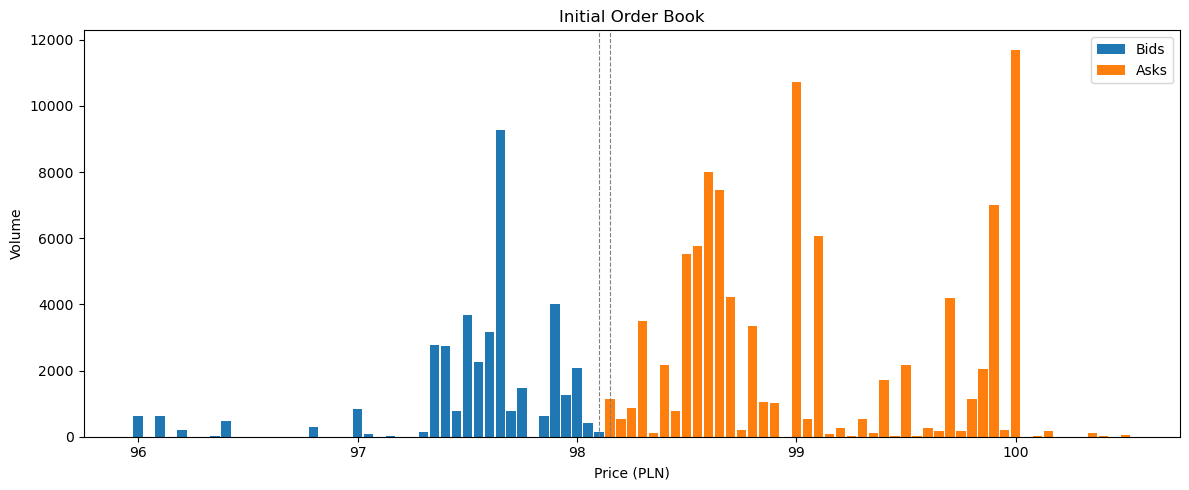

Best bid: 98.10
Best ask: 98.15
Spread: 0.05 (1 ticks)


In [3]:
T = 18433720  # number of events to simulate

ARRIVAL_MODE = "hawkes_multivariate"

db_path = str(helpers.project_root() / "data" / "sim_events_single_tenth.sqlite")

sim = Simulate(arrival_mode=ARRIVAL_MODE,
T=T, kernel_mode="single",
db_path=db_path)
tick_size = 0.05  # WSE tick size for KGHM at ~98 PLN

# Load a real orderbook snapshot from WSE data
# Available assets: KGHM, PKNORLEN, PKOBP, PEKAO, PZU
# Days: d20170103 to d20171229
sim.load_real_orderbook_snapshot( 
    asset="KGHM",
    day_key="d20170110",
    snapshot_time="10:00:00",  # After opening auction
    tick_size=tick_size,
)
sim.plot_book()


In [ ]:
sim.run(overwrite=True)

C:\Users\jaspe\Documents\CLS\Thesis\research_core\classes\simulate.py:1090: RuntimeWarning: invalid value encountered in divide
  y_vals = np.where(delta0s != 0, (opp_log - log_prices) / delta0s, 1.0)


[  50000]  bid_d= 1,163,424  ask_d=   784,626  n_bid=  403  n_ask=  391  LO= 25605  CXL= 22878  MO=  1517  guard_remap=0
[ 100000]  bid_d=   456,297  ask_d= 1,208,278  n_bid=  203  n_ask=  411  LO= 51182  CXL= 45788  MO=  3030  guard_remap=41
[ 150000]  bid_d=   477,347  ask_d=   394,944  n_bid=  200  n_ask=  210  LO= 76735  CXL= 68668  MO=  4597  guard_remap=157
[ 200000]  bid_d=   302,351  ask_d=   903,956  n_bid=  187  n_ask=  298  LO=102398  CXL= 91510  MO=  6092  guard_remap=281
[ 250000]  bid_d= 1,654,787  ask_d=   529,104  n_bid=  421  n_ask=  196  LO=128018  CXL=114334  MO=  7648  guard_remap=421
[ 300000]  bid_d=   791,680  ask_d=   708,820  n_bid=  290  n_ask=  184  LO=153590  CXL=137250  MO=  9160  guard_remap=448
[ 350000]  bid_d= 1,031,299  ask_d=   318,674  n_bid=  306  n_ask=  159  LO=179046  CXL=160228  MO= 10726  guard_remap=468
[ 400000]  bid_d=   967,548  ask_d=   251,815  n_bid=  343  n_ask=  158  LO=204789  CXL=183029  MO= 12182  guard_remap=651
[ 450000]  bid_d=  

KeyboardInterrupt: 

AnalyseMarket | sim_events_single_full.sqlite | simulation
  Tables: ['bbo', 'fills', 'intensities', 'mo_orders', 'orders']


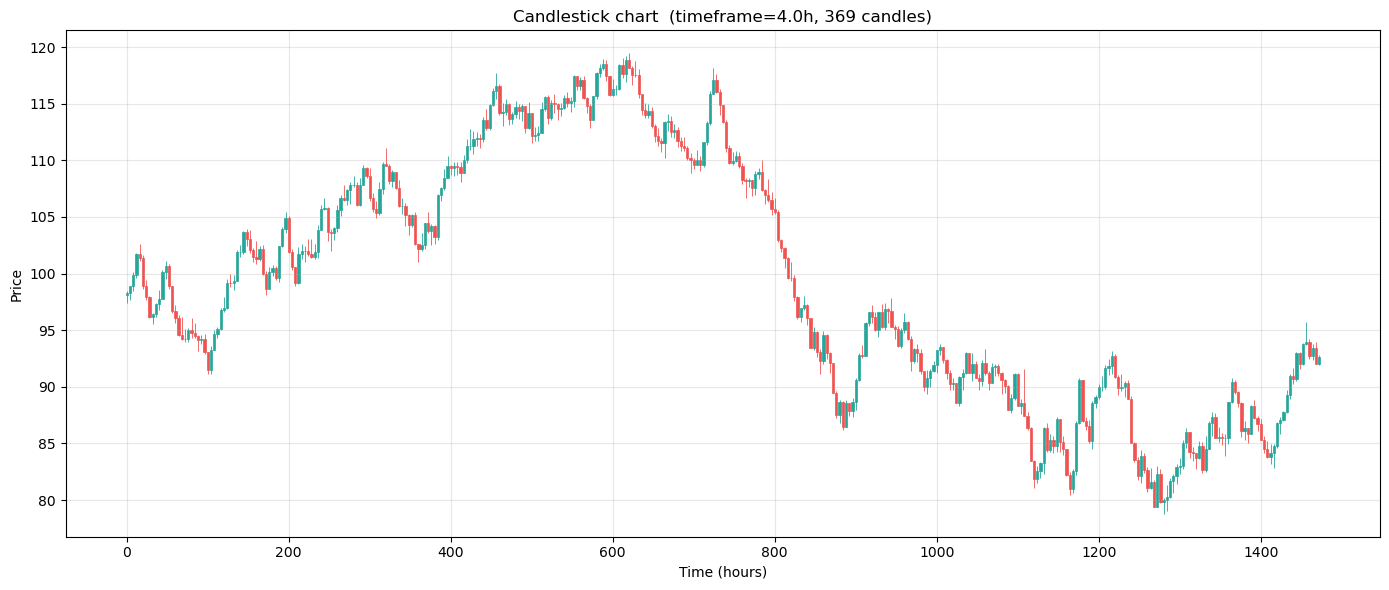

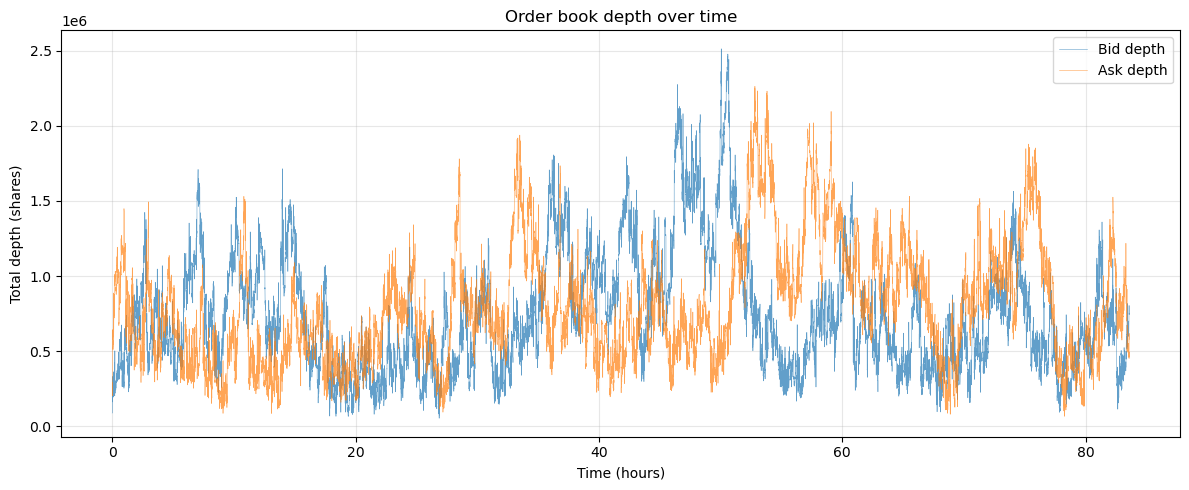

In [10]:
db_path = str(helpers.project_root() / "data" / "sim_events_single_full.sqlite")
am_single = AnalyseMarket(db_path, tick_size=tick_size)
am_single.plot_candlestick(timeframe=14400)
am_single.plot_depth(n_events=1_000_000, offset=0)

Full sign series length: 552,749 MOs,  buy fraction: 0.504
Power-law exponent:  γ = 1.1028   (ρ(k) ~ k^{-1.1028})


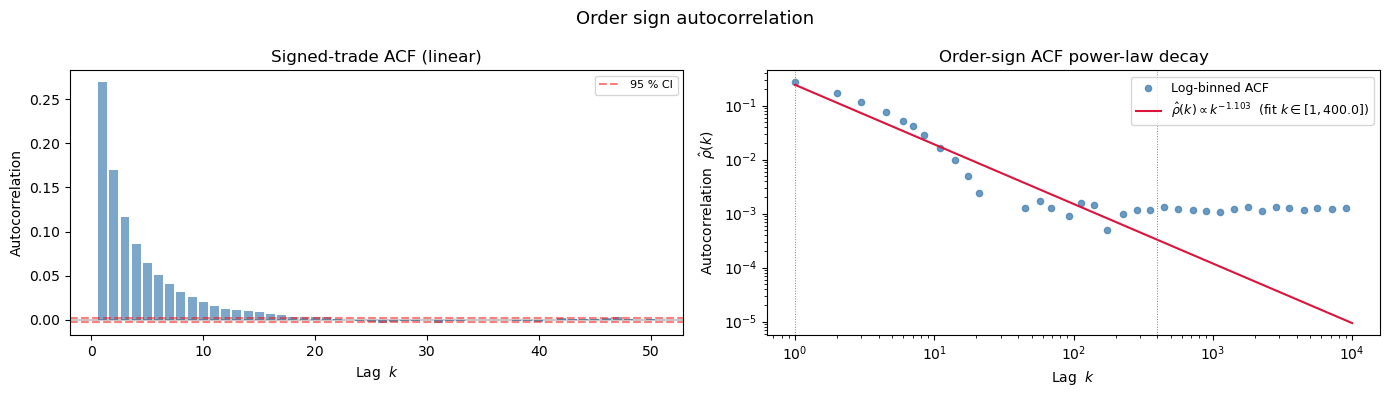

In [9]:
am_single.stylized_order_sign_autocorrelation(cap=400)

Propagator data (552,749 MOs):
  R(1) check: 73,902 pos (13.4%), 451,555 zero (81.7%), 27,291 neg (4.9%)
  Among price-moving: 73.0% positive (expect >> 50%)
  Mean R(1): 0.004349


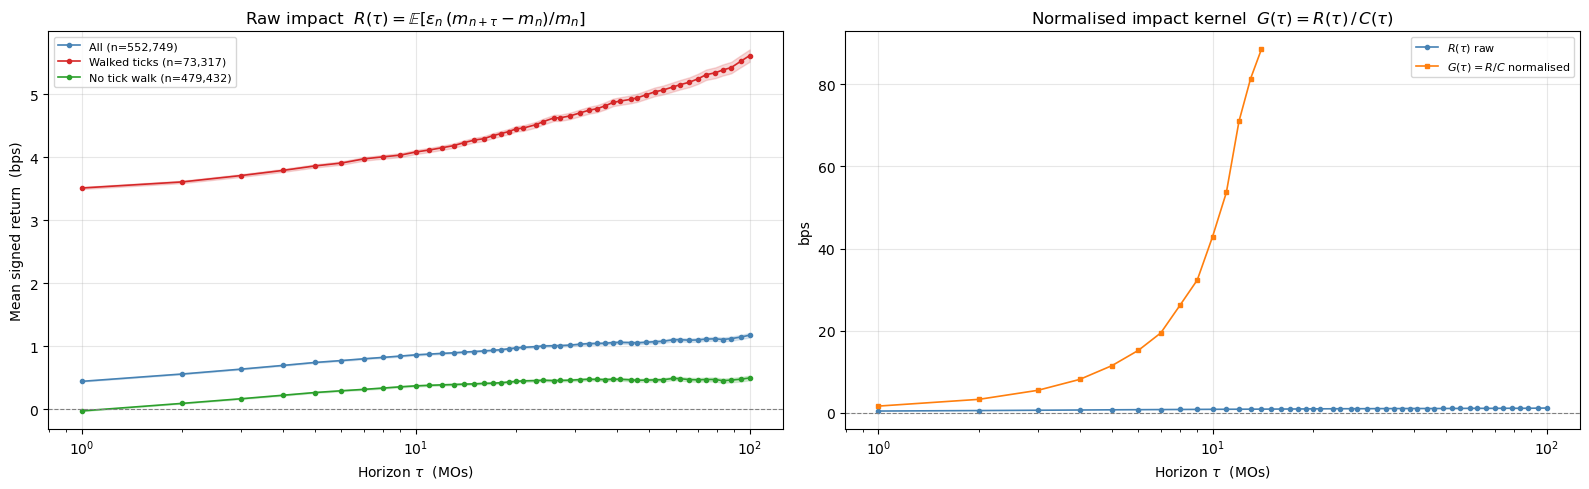

MOs total: 552,749
  walked ticks:    73,317
  no tick walk:    479,432
  R(1)  = +0.444 bps   C(1)  = 0.2690   G(1)  = +1.650 bps
  R(100) = +1.176 bps   C(100) = 0.0034   G(100) = n/a bps
  |C| > 0.01 for 14/47 horizons


In [10]:
am_single.price_impact_propagator(split_regimes=True)

Propagator data (552,749 MOs):
  R(1) check: 73,902 pos (13.4%), 451,555 zero (81.7%), 27,291 neg (4.9%)
  Among price-moving: 73.0% positive (expect >> 50%)
  Mean R(1): 0.004349


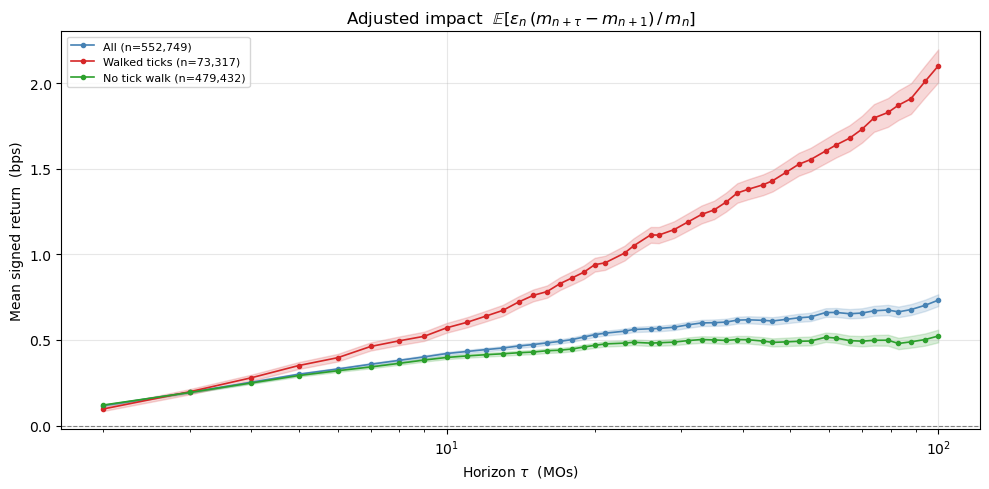

MOs total: 552,749
  walked ticks:    73,317
  no tick walk:    479,432
  tau =     2:  +0.117 bps
  tau =   100:  +0.733 bps


In [11]:
am_single.adjusted_impact_propagator(split_regimes=True)

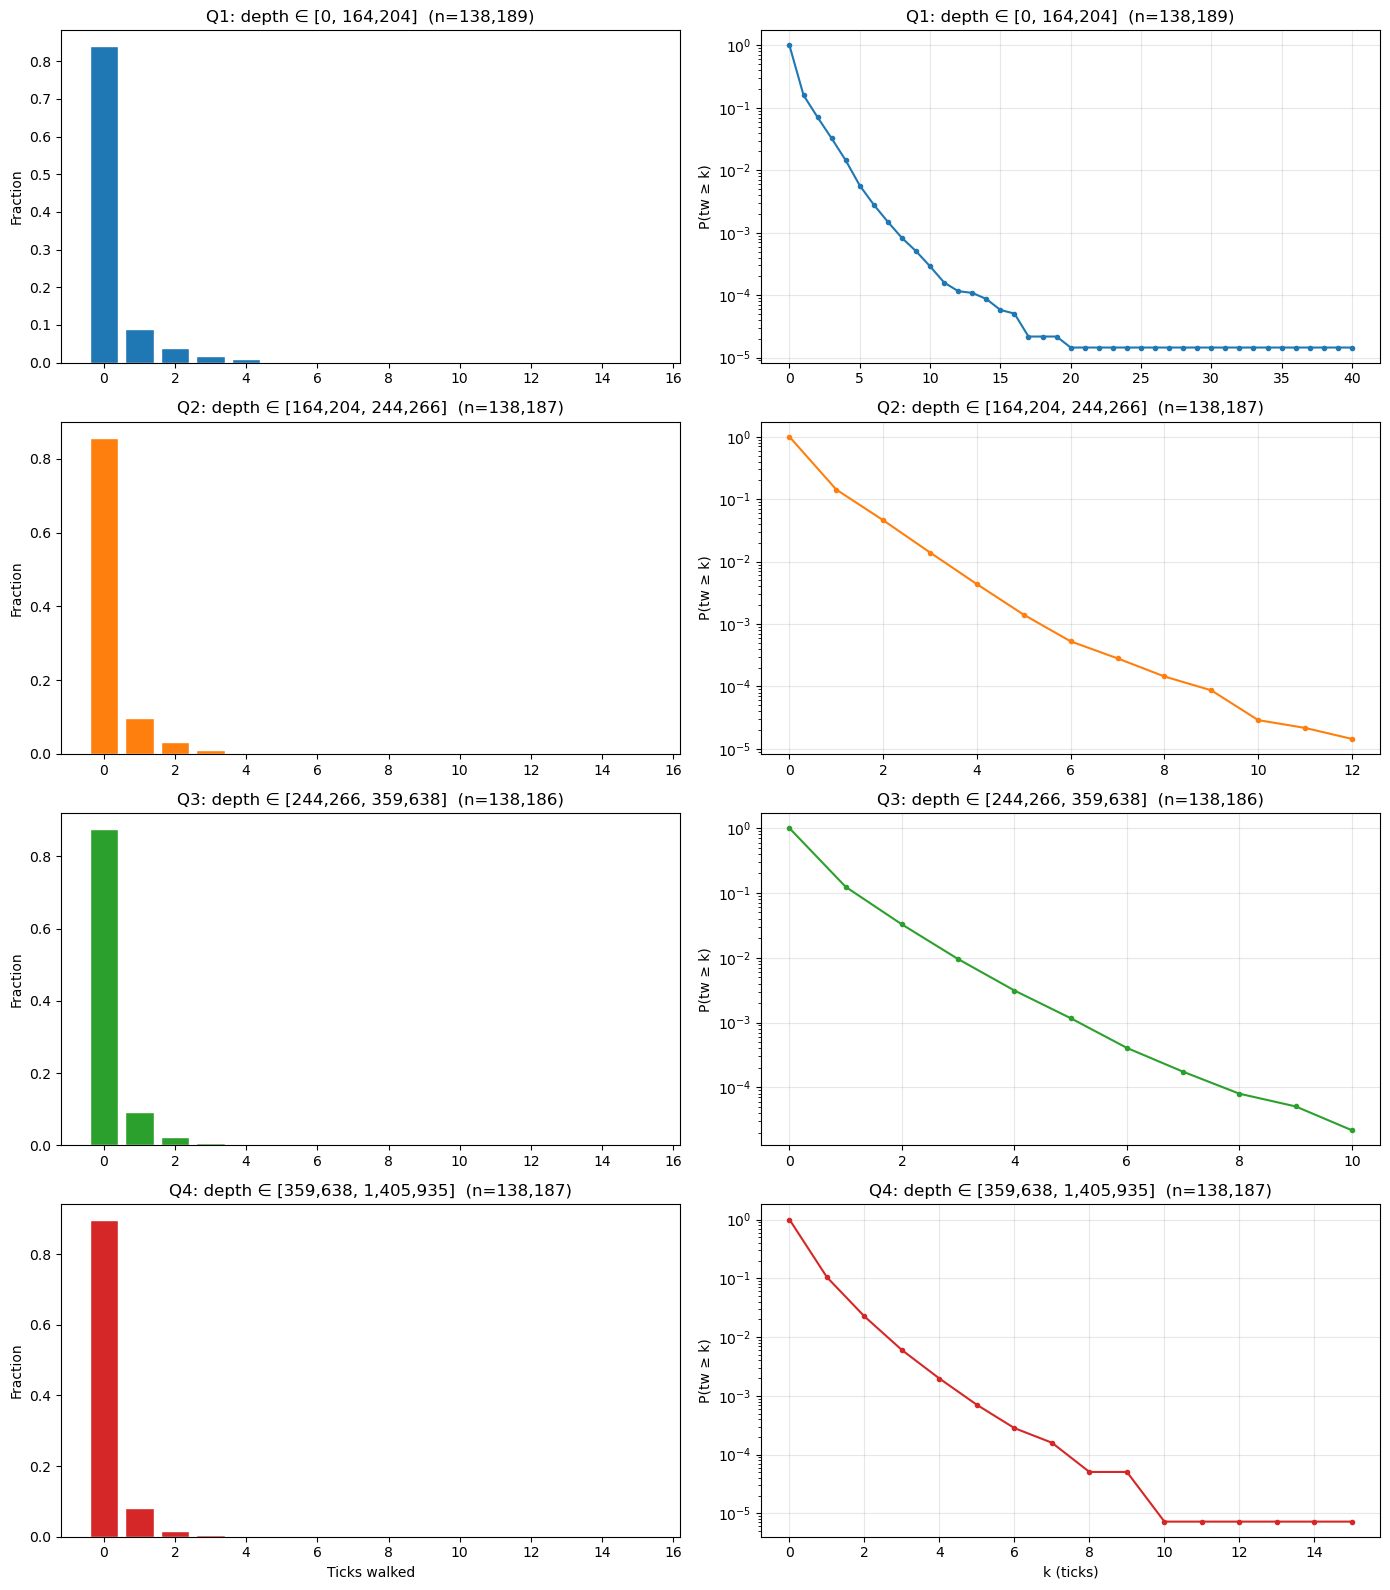


  Quartile         n   mean tw    P(>0)     P(≥5)
──────────────────────────────────────────────────
        Q1   138,189     0.290    16.0%     0.57%
        Q2   138,187     0.209    14.3%     0.14%
        Q3   138,186     0.171    12.4%     0.12%
        Q4   138,187     0.136    10.4%     0.07%


In [12]:
am_single.price_impact_by_depth()

In [3]:
# ═══════════════════════════════════════════════════════════════════════════════
# Compact analysis helpers — operate on in-memory dicts from get_compact_results()
# ═══════════════════════════════════════════════════════════════════════════════

def _auto_time_label(t_sec):
    """Choose minutes or hours scale for time axis."""
    span = t_sec.max() - t_sec.min() if len(t_sec) else 0
    if span > 7200:
        return t_sec / 3600.0, "Time (hours)", 3600.0
    elif span > 120:
        return t_sec / 60.0, "Time (minutes)", 60.0
    return t_sec, "Time (seconds)", 1.0


def plot_candlestick_compact(results, timeframe=60.0, ema_spans=None, title_suffix=""):
    """OHLC candlestick chart from compact fill data.

    Parameters
    ----------
    results : dict or list[dict]
        Output of Simulate.get_compact_results(), or a list of such dicts.
        If a list, the first run is plotted.
    timeframe : float
        Candle width in seconds (default 60 s).
    ema_spans : list[int] or None
        EMA spans (in number of candles) to overlay.
    title_suffix : str
        Extra text appended to the chart title.
    """
    if isinstance(results, list):
        results = results[0]
    t_sec = results['fills_ts']
    prices = results['fills_price']
    if len(t_sec) < 2:
        print("Not enough fill data for candlestick."); return

    t_min, t_max = t_sec[0], t_sec[-1]
    edges = np.arange(t_min, t_max + timeframe, timeframe)
    n_candles = len(edges) - 1
    if n_candles < 2:
        print(f"Only {n_candles} candle(s) — try a smaller timeframe."); return

    opens  = np.empty(n_candles)
    highs  = np.empty(n_candles)
    lows   = np.empty(n_candles)
    closes = np.empty(n_candles)
    c_times = np.empty(n_candles)

    idx = 0
    for ci in range(n_candles):
        lo_t, hi_t = edges[ci], edges[ci + 1]
        c_times[ci] = lo_t
        start = idx
        while idx < len(t_sec) and t_sec[idx] < hi_t:
            idx += 1
        end = idx
        if start == end:
            val = closes[ci - 1] if ci > 0 else prices[0]
            opens[ci] = highs[ci] = lows[ci] = closes[ci] = val
        else:
            seg = prices[start:end]
            opens[ci]  = closes[ci - 1] if ci > 0 else seg[0]
            highs[ci]  = max(seg.max(), opens[ci])
            lows[ci]   = min(seg.min(), opens[ci])
            closes[ci] = seg[-1]

    c_t, xlabel, divisor = _auto_time_label(c_times)
    candle_w = timeframe / divisor * 0.7

    ema_lines = {}
    if ema_spans:
        for span in ema_spans:
            alpha = 2.0 / (span + 1)
            ema = np.empty(n_candles)
            ema[0] = closes[0]
            for i in range(1, n_candles):
                ema[i] = alpha * closes[i] + (1 - alpha) * ema[i - 1]
            ema_lines[span] = ema

    fig, ax = plt.subplots(1, 1, figsize=(14, 6))
    up   = closes >= opens
    down = ~up
    col_up, col_down = "#26a69a", "#ef5350"

    ax.bar(c_t[up], closes[up] - opens[up], bottom=opens[up],
           width=candle_w, color=col_up, edgecolor=col_up, lw=0.5)
    ax.bar(c_t[down], opens[down] - closes[down], bottom=closes[down],
           width=candle_w, color=col_down, edgecolor=col_down, lw=0.5)
    ax.vlines(c_t[up], lows[up], highs[up], color=col_up, lw=0.6)
    ax.vlines(c_t[down], lows[down], highs[down], color=col_down, lw=0.6)

    ema_colors = ["#ff9800", "#2196f3", "#9c27b0", "#00bcd4"]
    for i, (span, ema_v) in enumerate(ema_lines.items()):
        ax.plot(c_t, ema_v, lw=1.2, color=ema_colors[i % len(ema_colors)],
                label=f"EMA {span}")

    ax.set_ylabel("Price")
    tf_lbl = (f"{timeframe:.0f}s" if timeframe < 60 else
              (f"{timeframe/60:.0f}min" if timeframe < 3600 else
               f"{timeframe/3600:.1f}h"))
    ax.set_title(f"Candlestick chart  (timeframe={tf_lbl}, "
                 f"{n_candles} candles){title_suffix}")
    if ema_lines:
        ax.legend(loc="upper left", fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_xlabel(xlabel)
    plt.tight_layout(); plt.show()


def _propagator_curve_pooled(mid_mo, sign, horizons, ref_shift=0, mask=None):
    """Propagator curve for a single run (no day boundaries)."""
    N = len(mid_mo)
    means = np.empty(len(horizons))
    ses = np.empty(len(horizons))
    for k, tau in enumerate(horizons):
        tau = int(tau)
        n_use = N - max(tau, ref_shift)
        if n_use < 10:
            means[k] = np.nan; ses[k] = 0; continue
        start = np.arange(n_use)
        if mask is not None:
            start = start[mask[:n_use]]
        if len(start) < 5:
            means[k] = np.nan; ses[k] = 0; continue
        s = sign[start]
        ref = mid_mo[start + ref_shift]
        fut = mid_mo[start + tau]
        base = mid_mo[start]
        r = s * (fut - ref) / base
        means[k] = r.mean()
        ses[k] = r.std() / np.sqrt(len(start))
    return means * 1e4, ses * 1e4


def _sign_autocorr(sign, horizons):
    """Order-sign autocorrelation C(τ) = E[ε_t · ε_{t+τ}]."""
    n = len(sign)
    acf = np.empty(len(horizons))
    for k, tau in enumerate(horizons):
        tau = int(tau)
        if tau >= n:
            acf[k] = 0.0
        else:
            acf[k] = np.mean(sign[:-tau] * sign[tau:])
    return acf


def price_impact_propagator_compact(results, max_horizon=100, n_points=80,
                                    split_regimes=False):
    """Propagator plot from compact MO data.

    For a list of runs, computes per-run curves and averages across runs.

    Parameters
    ----------
    results : dict or list[dict]
        Output of get_compact_results() (single) or list thereof.
    max_horizon : int
        Maximum MO-horizon.
    n_points : int
        Number of log-spaced horizons.
    split_regimes : bool
        If True, split by ticks_walked > 0.
    """
    if isinstance(results, dict):
        results = [results]

    horizons = np.unique(np.geomspace(1, max_horizon, n_points).astype(int))

    def _single_run_curves(res):
        mid_mo = ((res['mo_best_bid'] + res['mo_best_ask']) / 2.0).astype(np.float64)
        sign_all = np.where(res['mo_side'] == 'buy', 1.0, -1.0)
        tw = res['mo_ticks_walked'].astype(int)
        return mid_mo, sign_all, tw

    # ── Collect per-run curves ──
    all_R = []
    all_R_walked = []
    all_R_notwalk = []
    all_acf = []
    n_mos_total = 0

    for res in results:
        if len(res['mo_side']) < 100:
            continue
        mid_mo, sign_all, tw = _single_run_curves(res)
        N = len(mid_mo)
        n_mos_total += N

        m, se = _propagator_curve_pooled(mid_mo, sign_all, horizons)
        all_R.append(m)
        acf = _sign_autocorr(sign_all, horizons)
        all_acf.append(acf)

        if split_regimes:
            walked = tw > 0
            m_w, _ = _propagator_curve_pooled(mid_mo, sign_all, horizons, mask=walked)
            m_nw, _ = _propagator_curve_pooled(mid_mo, sign_all, horizons, mask=~walked)
            all_R_walked.append(m_w)
            all_R_notwalk.append(m_nw)

    if not all_R:
        print("Not enough MO data across all runs."); return

    # Average across runs
    R_mean = np.nanmean(all_R, axis=0)
    R_se = np.nanstd(all_R, axis=0) / np.sqrt(len(all_R)) if len(all_R) > 1 else np.zeros_like(R_mean)
    acf_mean = np.nanmean(all_acf, axis=0)

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # Left: raw impact R(τ)
    ax = axes[0]
    ax.plot(horizons, R_mean, "o-", ms=3, lw=1.2, color="steelblue",
            label=f"All ({n_mos_total:,} MOs, {len(all_R)} runs)")
    ax.fill_between(horizons, R_mean - R_se, R_mean + R_se, alpha=0.18, color="steelblue")

    if split_regimes and all_R_walked:
        Rw_mean = np.nanmean(all_R_walked, axis=0)
        Rnw_mean = np.nanmean(all_R_notwalk, axis=0)
        ax.plot(horizons, Rw_mean, "o-", ms=3, lw=1.2, color="tab:red", label="Walked ticks")
        ax.plot(horizons, Rnw_mean, "o-", ms=3, lw=1.2, color="tab:green", label="No tick walk")

    ax.axhline(0, ls="--", color="grey", lw=0.8)
    ax.set_xscale("log")
    ax.set_xlabel(r"Horizon $\tau$  (MOs)")
    ax.set_ylabel("Mean signed return  (bps)")
    ax.set_title(r"Raw impact  $R(\tau)$")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    # Right: normalised kernel G = R / C
    ax = axes[1]
    acf_thresh = 0.01
    G = np.full_like(R_mean, np.nan)
    acf_ok = np.abs(acf_mean) > acf_thresh
    G[acf_ok] = R_mean[acf_ok] / acf_mean[acf_ok]

    ax.plot(horizons, R_mean, "o-", ms=3, lw=1.2, color="steelblue",
            label=r"$R(\tau)$ raw")
    ax.plot(horizons[acf_ok], G[acf_ok], "s-", ms=3, lw=1.2,
            color="tab:orange", label=r"$G(\tau) = R/C$ normalised")
    ax.axhline(0, ls="--", color="grey", lw=0.8)
    ax.set_xscale("log")
    ax.set_xlabel(r"Horizon $\tau$  (MOs)")
    ax.set_ylabel("bps")
    ax.set_title(r"Normalised impact kernel  $G(\tau) = R(\tau)\,/\,C(\tau)$")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    plt.tight_layout(); plt.show()

    # Summary
    print(f"Runs: {len(all_R)},  total MOs: {n_mos_total:,}")
    g1 = f"{G[0]:+.3f}" if acf_ok[0] else "n/a"
    gl = f"{G[-1]:+.3f}" if acf_ok[-1] else "n/a"
    print(f"  R(1)  = {R_mean[0]:+.3f} bps   C(1)  = {acf_mean[0]:.4f}   G(1)  = {g1} bps")
    print(f"  R({horizons[-1]}) = {R_mean[-1]:+.3f} bps   "
          f"C({horizons[-1]}) = {acf_mean[-1]:.4f}   G({horizons[-1]}) = {gl} bps")


def _acf_fft(x, max_lag):
    """FFT-based autocorrelation."""
    x = np.asarray(x, dtype=float)
    n = len(x)
    if n < 2:
        return np.zeros(max_lag + 1)
    xc = x - x.mean()
    xf = np.fft.rfft(xc, n=2 * n)
    ac = np.fft.irfft(xf * np.conj(xf))[:max_lag + 1]
    if ac[0] != 0:
        ac /= ac[0]
    else:
        ac[:] = 0.0
    return ac  # ac[0] = 1, ac[k] = rho(k)


def order_sign_acf_compact(results, max_lag_bar=50, max_lag_loglog=10_000,
                           cap=800, n_log_bins=40):
    """Order-sign ACF with short-lag bar chart and log-log power-law fit.

    Parameters
    ----------
    results : dict or list[dict]
        Output of get_compact_results() or list thereof.
        If a list, MO signs are concatenated (each run treated independently
        is not needed since signs are stationary).
    """
    if isinstance(results, dict):
        results = [results]

    # Concatenate MO signs across runs
    all_signs = []
    for res in results:
        sides = res['mo_side']
        s = np.where(sides == 'buy', 1.0, -1.0)
        all_signs.append(s)
    signs = np.concatenate(all_signs) if all_signs else np.array([], dtype=float)

    if len(signs) < 50:
        print(f"Only {len(signs)} MOs — not enough for ACF."); return

    n = len(signs)
    buy_frac = (signs > 0).mean()
    print(f"Full sign series length: {n:,} MOs,  buy fraction: {buy_frac:.3f}")

    # ── Panel 1: Short-lag ACF (bar chart) ──
    max_bar = min(max_lag_bar, n - 1)
    acf_short = _acf_fft(signs, max_bar)
    lags_short = np.arange(1, max_bar + 1)
    ci = 1.96 / np.sqrt(n)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    axes[0].bar(lags_short, acf_short[1:], width=0.8, alpha=0.7, color="steelblue")
    axes[0].axhline(ci, ls="--", color="red", alpha=0.5, label="95 % CI")
    axes[0].axhline(-ci, ls="--", color="red", alpha=0.5)
    axes[0].axhline(0, lw=0.3, color="k")
    axes[0].set_xlabel("Lag  $k$")
    axes[0].set_ylabel("Autocorrelation")
    axes[0].set_title("Signed-trade ACF (linear)")
    axes[0].legend(fontsize=8)

    # ── Panel 2: Log-log ACF with power-law fit ──
    max_ll = min(max_lag_loglog, n - 1)
    acf_long = _acf_fft(signs, max_ll)
    lags_long = np.arange(1, max_ll + 1)
    acf_vals = acf_long[1:]

    pos_mask = acf_vals > 0
    if pos_mask.sum() >= 10:
        lags_pos = lags_long[pos_mask].astype(float)
        acf_pos = acf_vals[pos_mask]
        n_bins = int(max(5, n_log_bins))
        edges = np.unique(np.logspace(np.log10(lags_pos.min()),
                                      np.log10(lags_pos.max()),
                                      n_bins + 1))

        lag_bins, acf_bins = [], []
        for i in range(len(edges) - 1):
            if i == len(edges) - 2:
                in_bin = (lags_pos >= edges[i]) & (lags_pos <= edges[i + 1])
            else:
                in_bin = (lags_pos >= edges[i]) & (lags_pos < edges[i + 1])
            if in_bin.sum() == 0:
                continue
            lag_bins.append(np.exp(np.mean(np.log(lags_pos[in_bin]))))
            acf_bins.append(acf_pos[in_bin].mean())

        lag_bins = np.asarray(lag_bins, dtype=float)
        acf_bins = np.asarray(acf_bins, dtype=float)

        # OLS fit in log-space
        fit_lo = 10 ** 0
        fit_hi = min(float(cap), float(max_ll))
        fit_mask = (lag_bins >= fit_lo) & (lag_bins <= fit_hi) & (acf_bins > 0)
        if fit_mask.sum() >= 5:
            log_l = np.log(lag_bins[fit_mask])
            log_a = np.log(acf_bins[fit_mask])
            A = np.column_stack([np.ones_like(log_l), log_l])
            coefs = np.linalg.lstsq(A, log_a, rcond=None)[0]
            gamma_hat = -coefs[1]
            intercept = coefs[0]
            print(f"Power-law exponent:  \u03b3 = {gamma_hat:.4f}   "
                  f"(\u03c1(k) ~ k^{{-{gamma_hat:.4f}}})")
        else:
            gamma_hat = intercept = None
            print("Not enough positive log-binned points in fit range.")

        axes[1].scatter(lag_bins, acf_bins, s=20, alpha=0.8, color="steelblue",
                        label="Log-binned ACF")
        axes[1].axvline(fit_lo, ls=":", lw=0.7, color="grey")
        axes[1].axvline(fit_hi, ls=":", lw=0.7, color="grey")

        if gamma_hat is not None:
            xf = np.logspace(0, np.log10(max_ll), 200)
            yf = np.exp(intercept) * xf ** (-gamma_hat)
            axes[1].plot(xf, yf, color="crimson", lw=1.5,
                         label=(rf"$\hat\rho(k) \propto "
                                rf"k^{{-{gamma_hat:.3f}}}$  "
                                rf"(fit $k\in[{fit_lo},{fit_hi}]$)"))

        axes[1].set_xscale("log"); axes[1].set_yscale("log")
        axes[1].set_xlabel("Lag  $k$")
        axes[1].set_ylabel(r"Autocorrelation  $\hat\rho(k)$")
        axes[1].set_title("Order-sign ACF power-law decay")
        axes[1].legend(fontsize=9)
    else:
        axes[1].text(0.5, 0.5, "Not enough positive ACF values\nfor power-law fit",
                     transform=axes[1].transAxes, ha="center")
        axes[1].set_title("Log-log ACF")

    plt.suptitle("Order sign autocorrelation", fontsize=13)
    plt.tight_layout(); plt.show()


def plot_average_acf_compact(results, max_lag_loglog=10_000,
                             cap=800, n_log_bins=40):
    """Average per-run order-sign ACF in log-log scale with power-law fit.

    Computes ACF per run, averages pointwise across runs, then performs an
    OLS power-law fit on log-binned positive ACF values.
    """
    if isinstance(results, dict):
        results = [results]

    acf_runs = []
    for res in results:
        sides = res.get('mo_side', np.array([]))
        if len(sides) < 50:
            continue
        sign = np.where(sides == 'buy', 1.0, -1.0)
        lag_cap = min(int(max_lag_loglog), len(sign) - 1)
        if lag_cap < 10:
            continue
        acf = _acf_fft(sign, lag_cap)  # includes lag 0
        row = np.full(max_lag_loglog + 1, np.nan, dtype=float)
        row[:lag_cap + 1] = acf
        acf_runs.append(row)

    if not acf_runs:
        print("No runs with enough MO signs for average log-log ACF.")
        return

    A = np.vstack(acf_runs)
    acf_mean = np.nanmean(A, axis=0)
    lags = np.arange(1, max_lag_loglog + 1)
    acf_vals = acf_mean[1:]

    pos_mask = np.isfinite(acf_vals) & (acf_vals > 0)
    if pos_mask.sum() < 10:
        print("Not enough positive average-ACF values for log-log fit.")
        return

    lags_pos = lags[pos_mask].astype(float)
    acf_pos = acf_vals[pos_mask]

    n_bins = int(max(5, n_log_bins))
    edges = np.unique(np.logspace(np.log10(lags_pos.min()),
                                  np.log10(lags_pos.max()),
                                  n_bins + 1))

    lag_bins, acf_bins = [], []
    for i in range(len(edges) - 1):
        if i == len(edges) - 2:
            in_bin = (lags_pos >= edges[i]) & (lags_pos <= edges[i + 1])
        else:
            in_bin = (lags_pos >= edges[i]) & (lags_pos < edges[i + 1])
        if in_bin.sum() == 0:
            continue
        lag_bins.append(np.exp(np.mean(np.log(lags_pos[in_bin]))))
        acf_bins.append(acf_pos[in_bin].mean())

    lag_bins = np.asarray(lag_bins, dtype=float)
    acf_bins = np.asarray(acf_bins, dtype=float)

    fit_lo = 10 ** 0
    fit_hi = min(float(cap), float(max_lag_loglog))
    fit_mask = (lag_bins >= fit_lo) & (lag_bins <= fit_hi) & (acf_bins > 0)

    gamma_hat = intercept = None
    if fit_mask.sum() >= 5:
        log_l = np.log(lag_bins[fit_mask])
        log_a = np.log(acf_bins[fit_mask])
        X = np.column_stack([np.ones_like(log_l), log_l])
        coefs = np.linalg.lstsq(X, log_a, rcond=None)[0]
        gamma_hat = -coefs[1]
        intercept = coefs[0]

    plt.figure(figsize=(10.5, 5.0))
    plt.scatter(lag_bins, acf_bins, s=22, alpha=0.85, color="steelblue",
                label="Average log-binned ACF")
    plt.axvline(fit_lo, ls=":", lw=0.8, color="grey")
    plt.axvline(fit_hi, ls=":", lw=0.8, color="grey")

    if gamma_hat is not None:
        xf = np.logspace(np.log10(max(1.0, lag_bins.min())),
                         np.log10(lag_bins.max()), 200)
        yf = np.exp(intercept) * xf ** (-gamma_hat)
        plt.plot(xf, yf, color="crimson", lw=1.6,
                 label=(rf"fit: $\hat\rho(k) \propto k^{{-{gamma_hat:.3f}}}$  "
                        rf"($k\in[{fit_lo:.0f},{fit_hi:.0f}]$)"))
        print(f"Average ACF power-law exponent:  γ = {gamma_hat:.4f}  "
              f"(from {len(acf_runs)} runs)")
    else:
        print("Not enough positive log-binned points in fit range.")

    plt.xscale("log"); plt.yscale("log")
    plt.xlabel("Lag  k")
    plt.ylabel(r"Average autocorrelation  $\hat\rho(k)$")
    plt.title(f"Average log-log order-sign ACF across {len(acf_runs)} runs")
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=9)
    plt.tight_layout()
    plt.show()


def plot_final_price_histogram_compact(results, bins=20):
    """Histogram of price change (final - first fill price) per run."""
    if isinstance(results, dict):
        results = [results]

    price_changes = []
    for res in results:
        p = res.get('fills_price', np.array([]))
        if len(p) < 2:
            continue
        price_changes.append(float(p[-1]) - float(p[0]))

    if not price_changes:
        print("No price changes available (runs have < 2 fills).")
        return

    dc = np.array(price_changes, dtype=float)
    n_up = (dc > 0).sum()
    n_down = (dc < 0).sum()
    n_flat = (dc == 0).sum()

    plt.figure(figsize=(9, 4.5))
    colors = ['#ef5350' if v < 0 else '#26a69a' for v in
              np.histogram_bin_edges(dc, bins=bins)[:-1]]
    _, bin_edges, patches = plt.hist(dc, bins=bins, color="slateblue",
                                     alpha=0.8, edgecolor="white")
    for patch, edge in zip(patches, bin_edges[:-1]):
        patch.set_facecolor('#ef5350' if edge < 0 else '#26a69a')
    plt.axvline(0, color="grey", lw=1.0, ls="-", alpha=0.6)
    plt.axvline(dc.mean(), color="crimson", lw=1.4, ls="--",
                label=f"mean = {dc.mean():+.4f}")
    plt.axvline(np.median(dc), color="darkgreen", lw=1.4, ls=":",
                label=f"median = {np.median(dc):+.4f}")
    plt.xlabel("Price change per run  (final - first, ticks)")
    plt.ylabel("Count")
    plt.title(f"Price change distribution across {len(dc)} runs  "
              f"(↑{n_up}  ↓{n_down}  ={n_flat})")
    plt.grid(True, alpha=0.25)
    plt.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

    print(f"Price change stats: min={dc.min():+.4f}, max={dc.max():+.4f}, "
          f"mean={dc.mean():+.4f}, std={dc.std(ddof=0):.4f}")


print("Compact analysis helpers loaded: plot_candlestick_compact, "
      "price_impact_propagator_compact, order_sign_acf_compact, "
      "plot_average_acf_compact, plot_final_price_histogram_compact")

Compact analysis helpers loaded: plot_candlestick_compact, price_impact_propagator_compact, order_sign_acf_compact, plot_average_acf_compact, plot_final_price_histogram_compact


In [4]:
def _run_lightweight(run_id, T, arrival_mode, kernel_mode,
                     asset, day_key, snap_time, tick_size):
    """Worker function for one lightweight simulation run.

    All arguments are plain Python types so joblib/loky can pickle them.
    Returns a dict of compact numpy arrays.
    """

    # Seed each worker independently (run_id + system entropy)
    seed = int.from_bytes(os.urandom(4), 'little') ^ (run_id * 999_983)
    np.random.seed(seed & 0xFFFF_FFFF)
    _random.seed(seed)

    # Suppress print output from snapshot loading
    _devnull = open(os.devnull, "w")
    _old_stdout = sys.stdout
    sys.stdout = _devnull
    try:
        sim = Simulate(
            arrival_mode=arrival_mode,
            T=T,
            kernel_mode=kernel_mode,
            lightweight=True,           # ← compact data only
        )
        sim.load_real_orderbook_snapshot(
            asset=asset,
            day_key=day_key,
            snapshot_time=snap_time,
            tick_size=tick_size,
        )
        sim.run()
    finally:
        sys.stdout = _old_stdout
        _devnull.close()

    result = sim.get_compact_results()
    result['run_id'] = run_id
    # Add a lightweight summary
    result['summary'] = {
        'n_fills': len(result['fills_ts']),
        'n_mos': len(result['mo_ts']),
        'n_buy': int((result['mo_side'] == 'buy').sum()),
        'n_sell': int((result['mo_side'] == 'sell').sum()),
    }
    return result

In [11]:
# ═══════════════════════════════════════════════════════════════════════════════
# Parallel lightweight simulations  (12 workers)
# ═══════════════════════════════════════════════════════════════════════════════


# ── Configuration ──────────────────────────────────────────────────────────
N_RUNS       = 500              # number of independent simulations
MAX_WORKERS  = 12              # parallel processes (one per CPU core)
T_PARALLEL   = 184337         # events per simulation (match the single-run T)
ARRIVAL_MODE = "hawkes_multivariate"
KERNEL_MODE  = "single"

# Snapshot parameters (same as the main sim)
SNAPSHOT_ASSET = "KGHM"
SNAPSHOT_DAY   = "d20170110"
SNAPSHOT_TIME  = "10:00:00"
SNAPSHOT_TICK  = 0.05


# ── Launch parallel runs ──────────────────────────────────────────────────
print(f"Launching {N_RUNS} lightweight simulations "
      f"({MAX_WORKERS} workers, {T_PARALLEL:,} events each)...")
t0 = _time.time()

all_results_up = Parallel(n_jobs=MAX_WORKERS, verbose=10)(
    delayed(_run_lightweight)(
        i, T_PARALLEL, ARRIVAL_MODE, KERNEL_MODE,
        SNAPSHOT_ASSET, SNAPSHOT_DAY, SNAPSHOT_TIME, SNAPSHOT_TICK,
    )
    for i in range(N_RUNS)
)

elapsed = _time.time() - t0
print(f"\nDone in {elapsed:.1f}s  ({elapsed/N_RUNS:.1f}s per run)")
print(f"Collected {len(all_results_up)} runs:")
for r in all_results_up:
    s = r['summary']
    print(f"  run {r['run_id']:>2d}: {s['n_fills']:>7,} fills, "
          f"{s['n_mos']:>6,} MOs  (buy={s['n_buy']:,}, sell={s['n_sell']:,})")

Launching 500 lightweight simulations (12 workers, 184,337 events each)...


[Parallel(n_jobs=12)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done   1 tasks      | elapsed:  1.4min
[Parallel(n_jobs=12)]: Done   8 tasks      | elapsed:  1.5min
[Parallel(n_jobs=12)]: Done  17 tasks      | elapsed:  2.7min
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:  4.0min
[Parallel(n_jobs=12)]: Done  37 tasks      | elapsed:  5.2min
[Parallel(n_jobs=12)]: Done  48 tasks      | elapsed:  5.4min
[Parallel(n_jobs=12)]: Done  61 tasks      | elapsed:  7.8min
[Parallel(n_jobs=12)]: Done  74 tasks      | elapsed:  9.1min
[Parallel(n_jobs=12)]: Done  89 tasks      | elapsed: 10.4min
[Parallel(n_jobs=12)]: Done 104 tasks      | elapsed: 11.8min
[Parallel(n_jobs=12)]: Done 121 tasks      | elapsed: 14.5min
[Parallel(n_jobs=12)]: Done 138 tasks      | elapsed: 16.1min
[Parallel(n_jobs=12)]: Done 157 tasks      | elapsed: 18.8min
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed: 20.5min
[Parallel(n_jobs=12)]: Done 197 tasks      | elapsed: 2


Done in 3452.0s  (6.9s per run)
Collected 500 runs:
  run  0:  15,888 fills,  5,695 MOs  (buy=2,932, sell=2,763)
  run  1:  15,776 fills,  5,249 MOs  (buy=2,745, sell=2,504)
  run  2:  16,072 fills,  5,613 MOs  (buy=2,930, sell=2,683)
  run  3:  16,132 fills,  5,694 MOs  (buy=2,903, sell=2,791)
  run  4:  15,153 fills,  5,538 MOs  (buy=2,941, sell=2,597)
  run  5:  15,772 fills,  5,557 MOs  (buy=2,712, sell=2,845)
  run  6:  15,843 fills,  5,712 MOs  (buy=2,986, sell=2,726)
  run  7:  16,005 fills,  5,727 MOs  (buy=2,811, sell=2,916)
  run  8:  15,714 fills,  5,757 MOs  (buy=2,940, sell=2,817)
  run  9:  15,784 fills,  5,693 MOs  (buy=2,995, sell=2,698)
  run 10:  16,093 fills,  5,754 MOs  (buy=3,027, sell=2,727)
  run 11:  15,496 fills,  5,474 MOs  (buy=2,781, sell=2,693)
  run 12:  14,908 fills,  5,452 MOs  (buy=2,879, sell=2,573)
  run 13:  15,976 fills,  5,810 MOs  (buy=3,063, sell=2,747)
  run 14:  16,152 fills,  5,711 MOs  (buy=2,933, sell=2,778)
  run 15:  16,103 fills,  5,613 

[Parallel(n_jobs=12)]: Done 500 out of 500 | elapsed: 57.5min finished


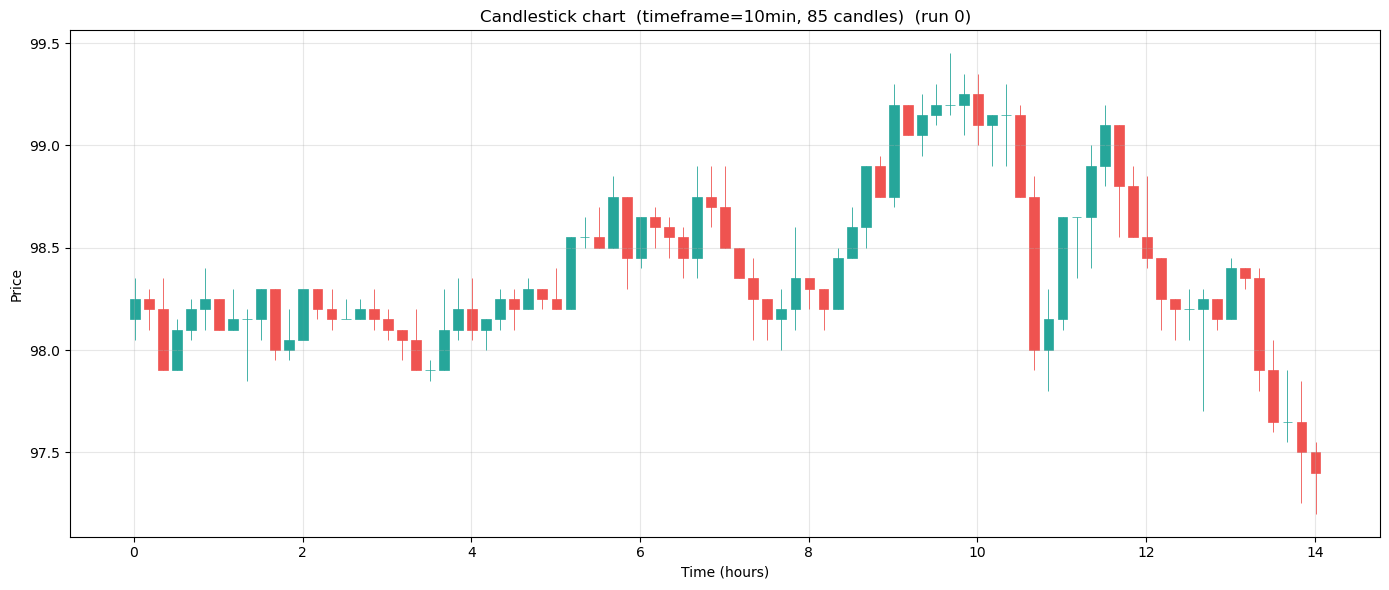

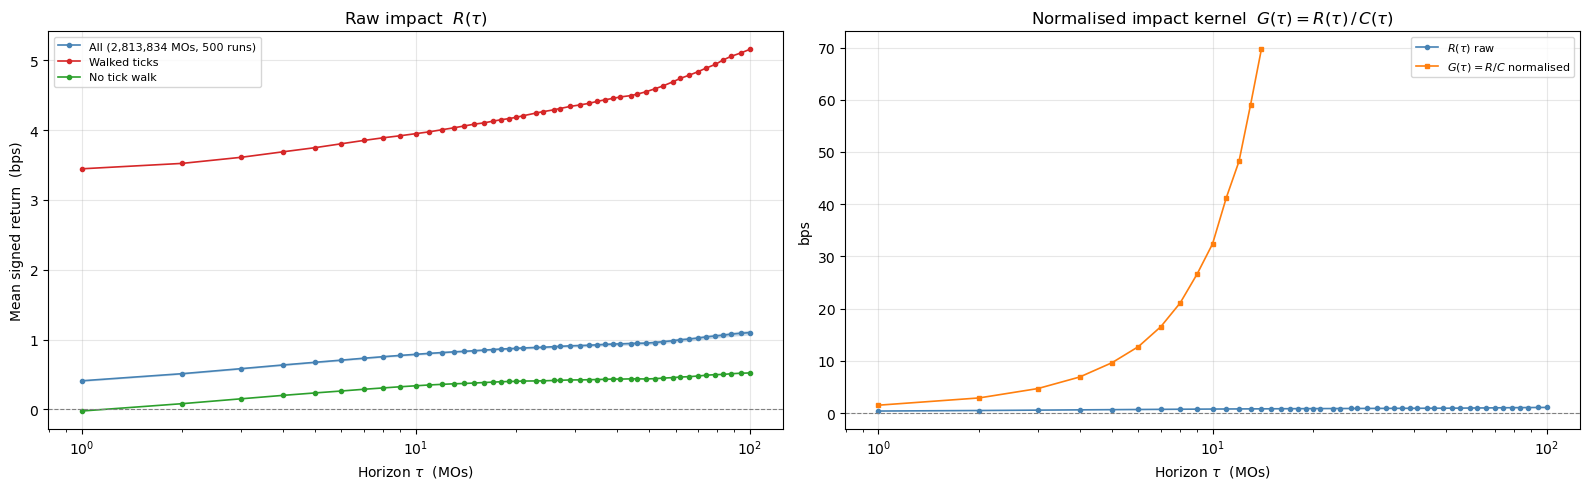

Runs: 500,  total MOs: 2,813,834
  R(1)  = +0.408 bps   C(1)  = 0.2672   G(1)  = +1.528 bps
  R(100) = +1.099 bps   C(100) = 0.0010   G(100) = n/a bps
Full sign series length: 2,813,834 MOs,  buy fraction: 0.516
Power-law exponent:  γ = 1.1569   (ρ(k) ~ k^{-1.1569})


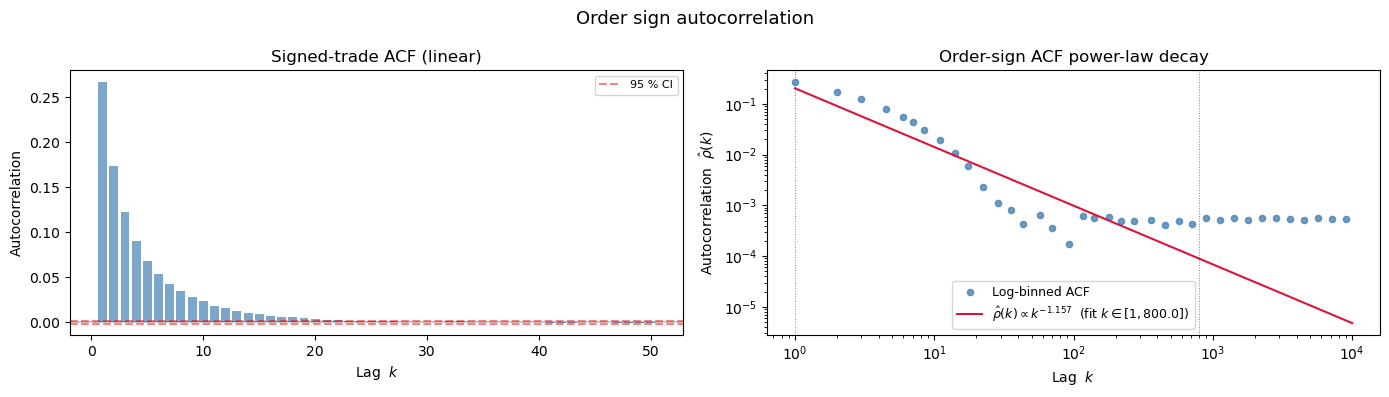

C:\Users\jaspe\AppData\Local\Temp\ipykernel_79268\1822912905.py:426: RuntimeWarning: Mean of empty slice
  acf_mean = np.nanmean(A, axis=0)


Average ACF power-law exponent:  γ = 1.9816  (from 500 runs)


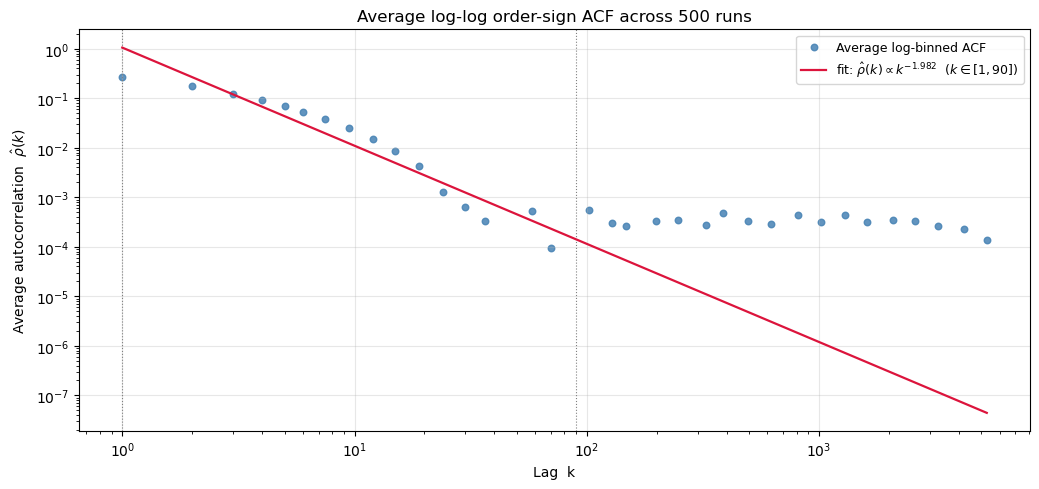

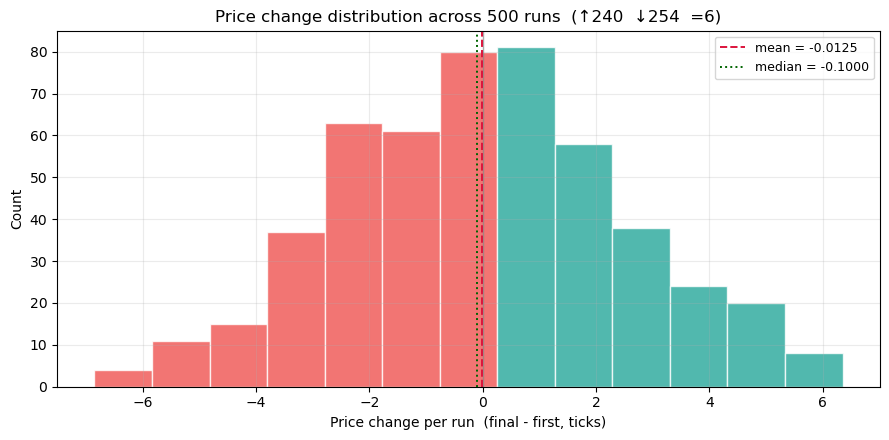

Price change stats: min=-6.8500, max=+6.3500, mean=-0.0125, std=2.5212


In [12]:
# ═══════════════════════════════════════════════════════════════════════════════
# Analyse parallel results — candlestick, propagator, ACF, final-price dispersion
# ═══════════════════════════════════════════════════════════════════════════════

# Candlestick for a single run (run 0)
plot_candlestick_compact(all_results_up[1], timeframe=600.0, title_suffix="  (run 0)")

# Price-impact propagator averaged across all runs
price_impact_propagator_compact(all_results_up, max_horizon=100,
                                split_regimes=True)

# Order-sign ACF pooled across all runs (legacy helper)
order_sign_acf_compact(all_results_up)

# Average per-run ACF in log-log scale + power-law fit (new helper)
plot_average_acf_compact(all_results_up, max_lag_loglog=10_000,
                         cap=90, n_log_bins=37)

# Histogram of each run's final traded price (new helper)
plot_final_price_histogram_compact(all_results_up, bins=13)

Loading KGHM orders for d20170110...
Replaying orders up to 2017-01-10 10:00:00+01:00...
Real BBO at snapshot: bid=98.08, ask=98.14, spread=0.06
Real book has 868 orders


C:\Users\jaspe\Documents\CLS\Thesis\research_core\classes\simulate.py:1280: RuntimeWarning: divide by zero encountered in log
  log_price = np.log(price_ticks)
C:\Users\jaspe\Documents\CLS\Thesis\research_core\classes\simulate.py:1308: RuntimeWarning: invalid value encountered in scalar divide
  y = delta_now / delta0_log



Loaded 243 bids, 625 asks into simulation
order_id_counter starts at 104703
Bid depth: 77,111, Ask depth: 187,676

Pre-existing order y distribution:
  mean=nan, median=nan, min=nan, max=nan
  y < 0.5 (near execution): 155
  0.5 ≤ y ≤ 1.5 (near placement): 664
  y > 1.5 (stranded): 33

Hawkes seeded with 33,802 real events:
      MO_bid:     142 events
      MO_ask:      43 events
      LO_bid:   8,549 events
      LO_ask:   9,193 events
     CXL_bid:   8,165 events
     CXL_ask:   7,710 events

Initial intensities at t=0 (baseline → seeded):
  λ( MO_bid) = 0.006055  (baseline 0.005766,  excitation +0.000289)
  λ( MO_ask) = 0.006027  (baseline 0.005766,  excitation +0.000261)
  λ( LO_bid) = 0.000000  (baseline 0.000000,  excitation +0.000000)
  λ( LO_ask) = 0.000000  (baseline 0.000000,  excitation +0.000000)
  λ(CXL_bid) = 0.099294  (baseline 0.000000,  excitation +0.099294)
  λ(CXL_ask) = 0.090649  (baseline 0.000000,  excitation +0.090649)


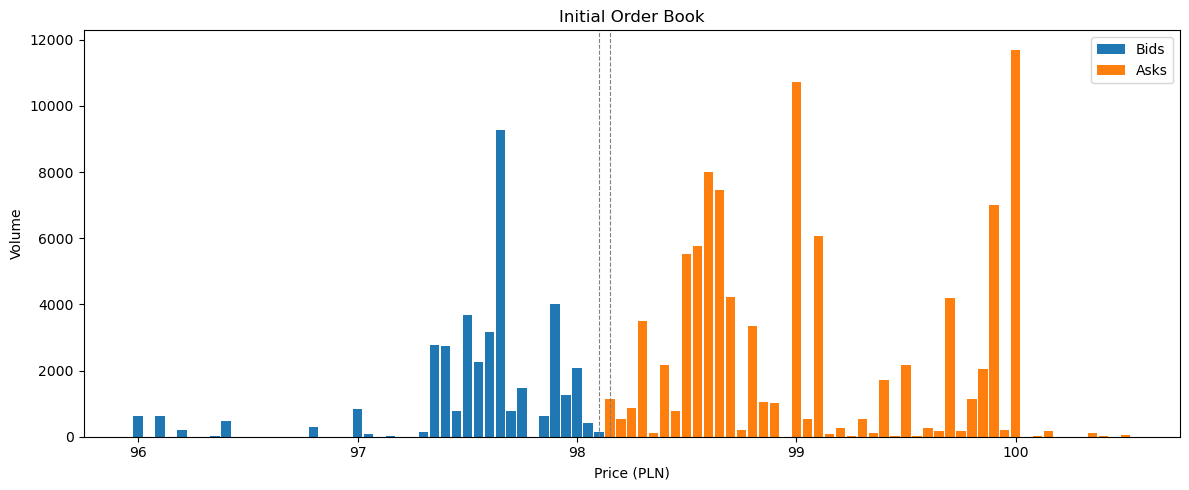

Best bid: 98.10
Best ask: 98.15
Spread: 0.05 (1 ticks)


In [5]:
T = 18433720  # number of events to simulate

ARRIVAL_MODE = "hawkes_multivariate"

db_path_triple = str(helpers.project_root() / "data" / "sim_events_triple_full.sqlite")

sim = Simulate(arrival_mode=ARRIVAL_MODE,
T=T, kernel_mode="triple",
db_path=db_path_triple)
tick_size = 0.05  # WSE tick size for KGHM at ~98 PLN

# Load a real orderbook snapshot from WSE data
# Available assets: KGHM, PKNORLEN, PKOBP, PEKAO, PZU
# Days: d20170103 to d20171229
sim.load_real_orderbook_snapshot( 
    asset="KGHM",
    day_key="d20170110",
    snapshot_time="10:00:00",  # After opening auction
    tick_size=tick_size,
)
sim.plot_book()


In [8]:
sim.run(overwrite=True)

C:\Users\jaspe\Documents\CLS\Thesis\research_core\classes\simulate.py:1090: RuntimeWarning: invalid value encountered in divide
  y_vals = np.where(delta0s != 0, (opp_log - log_prices) / delta0s, 1.0)


[  50000]  bid_d=   209,250  ask_d=   324,579  n_bid=  176  n_ask=  283  LO= 25172  CXL= 21838  MO=  2990  guard_remap=60
[ 100000]  bid_d=   414,043  ask_d=   824,504  n_bid=  191  n_ask=  247  LO= 50214  CXL= 43617  MO=  6169  guard_remap=156
[ 150000]  bid_d=   609,184  ask_d=   708,700  n_bid=  191  n_ask=  249  LO= 75492  CXL= 65278  MO=  9230  guard_remap=235
[ 200000]  bid_d=   589,543  ask_d=   819,080  n_bid=  167  n_ask=  253  LO=100779  CXL= 87090  MO= 12131  guard_remap=262
[ 250000]  bid_d=   261,868  ask_d=   481,049  n_bid=  138  n_ask=  171  LO=125857  CXL=108911  MO= 15232  guard_remap=318
[ 300000]  bid_d=   698,556  ask_d=   321,891  n_bid=  210  n_ask=  139  LO=151071  CXL=130666  MO= 18263  guard_remap=431
[ 350000]  bid_d=   243,971  ask_d=   779,986  n_bid=  143  n_ask=  216  LO=176164  CXL=152654  MO= 21182  guard_remap=522
[ 400000]  bid_d=   524,302  ask_d=   332,865  n_bid=  190  n_ask=  105  LO=201283  CXL=174525  MO= 24192  guard_remap=569
[ 450000]  bid_d=

AnalyseMarket | sim_events_triple_full.sqlite | simulation
  Tables: ['bbo', 'fills', 'intensities', 'mo_orders', 'orders']


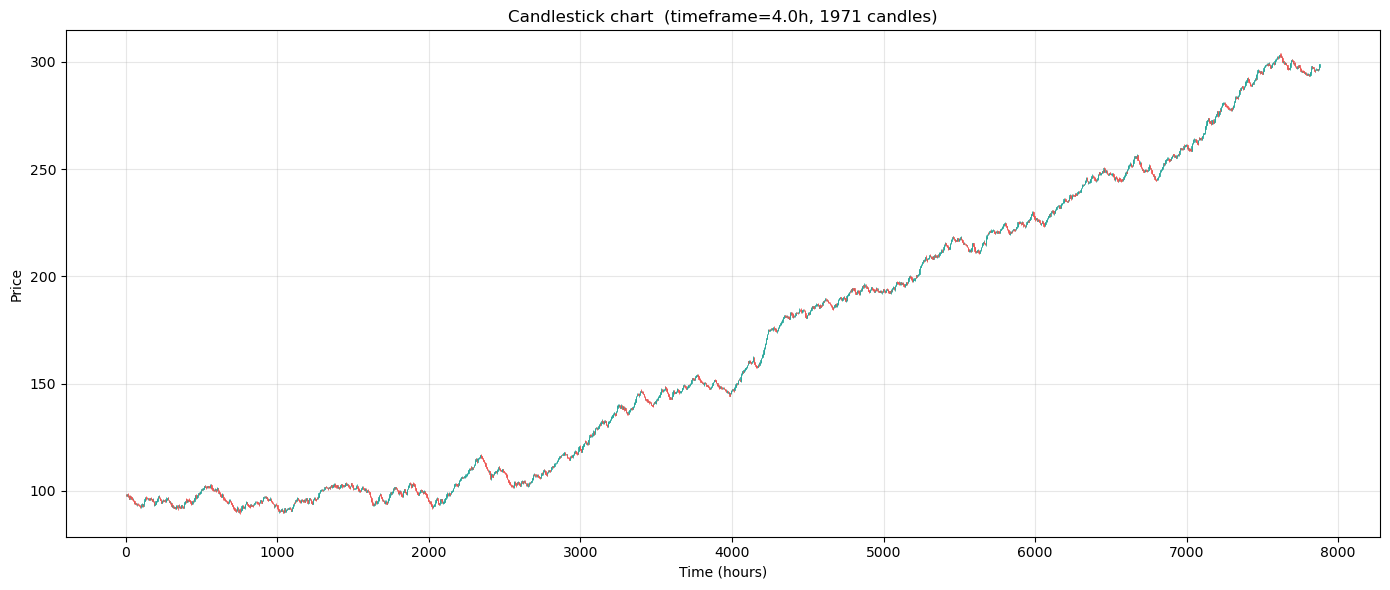

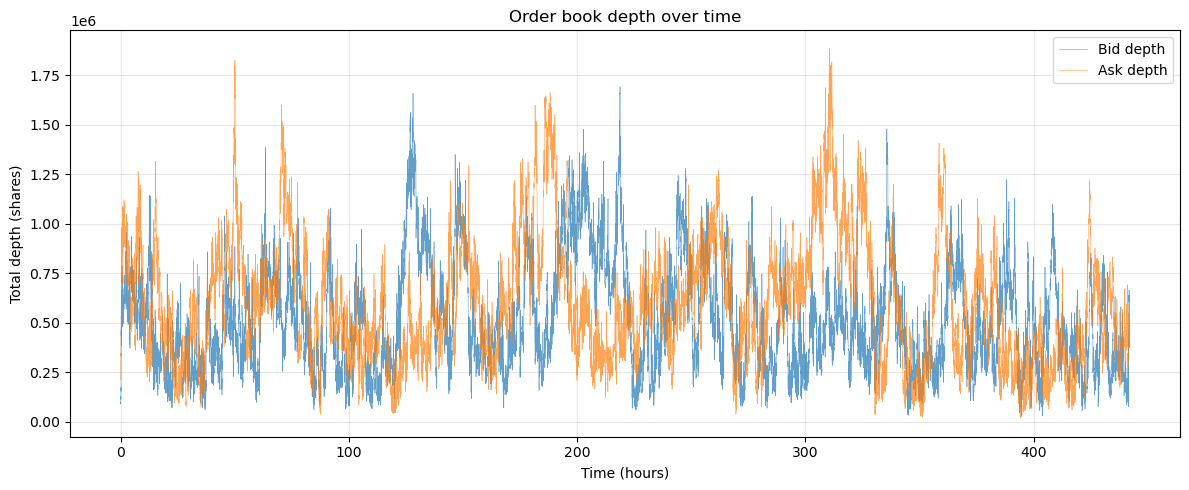

In [9]:
db_path_triple = str(helpers.project_root() / "data" / "sim_events_triple_full.sqlite")
am_triple = AnalyseMarket(db_path_triple, tick_size=tick_size)
am_triple.plot_candlestick(timeframe=14400)
am_triple.plot_depth(n_events=1_000_000, offset=0)

Propagator data (748,224 MOs):
  R(1) check: 101,442 pos (13.6%), 608,266 zero (81.3%), 38,515 neg (5.1%)
  Among price-moving: 72.5% positive (expect >> 50%)
  Mean R(1): 0.004098


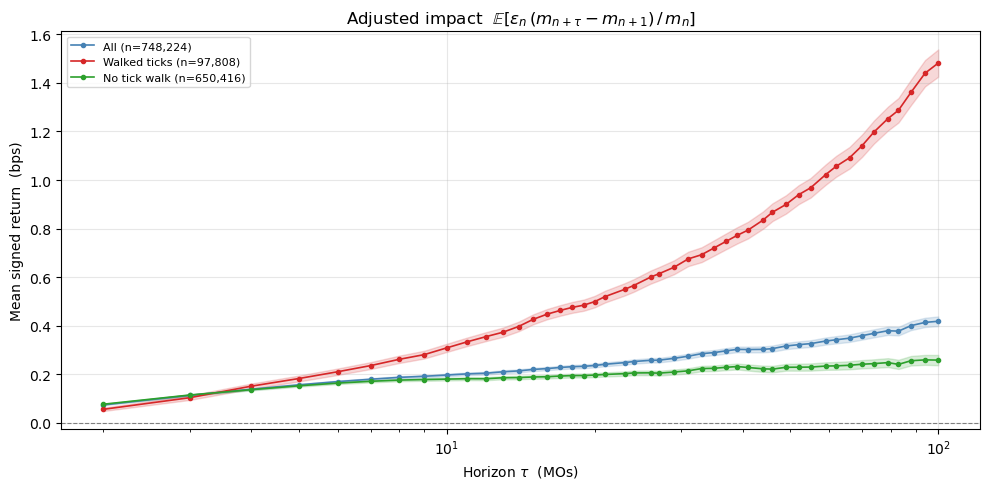

MOs total: 748,224
  walked ticks:    97,808
  no tick walk:    650,416
  tau =     2:  +0.074 bps
  tau =   100:  +0.418 bps


In [16]:
am_triple.adjusted_impact_propagator(split_regimes=True)

Full sign series length: 1,127,376 MOs,  buy fraction: 0.502
Power-law exponent:  γ = 1.0664   (ρ(k) ~ k^{-1.0664})


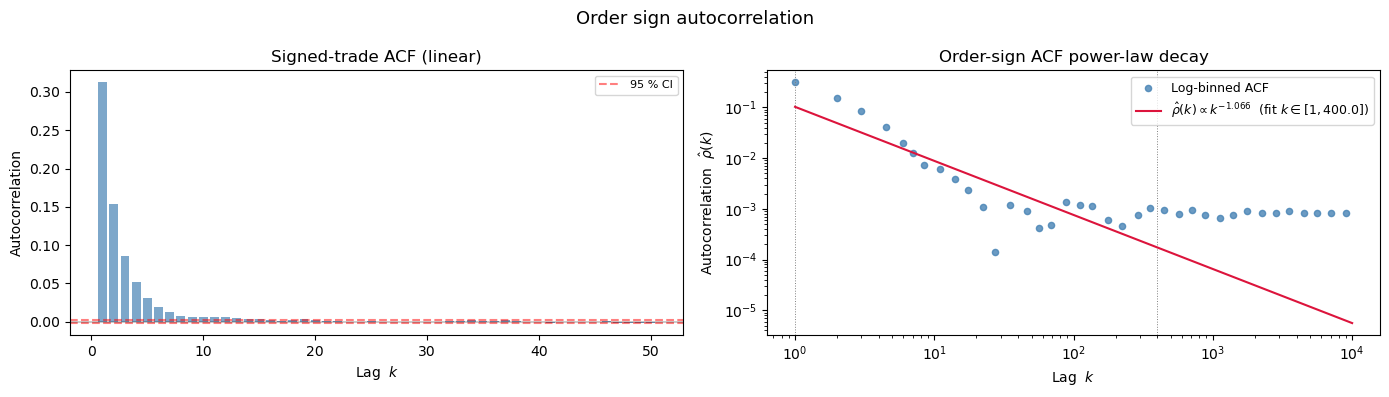

In [7]:
am_triple.stylized_order_sign_autocorrelation(cap=400)

Propagator data (107,293 MOs):
  R(1) check: 15,708 pos (14.6%), 84,949 zero (79.2%), 6,635 neg (6.2%)
  Among price-moving: 70.3% positive (expect >> 50%)
  Mean R(1): 0.003944


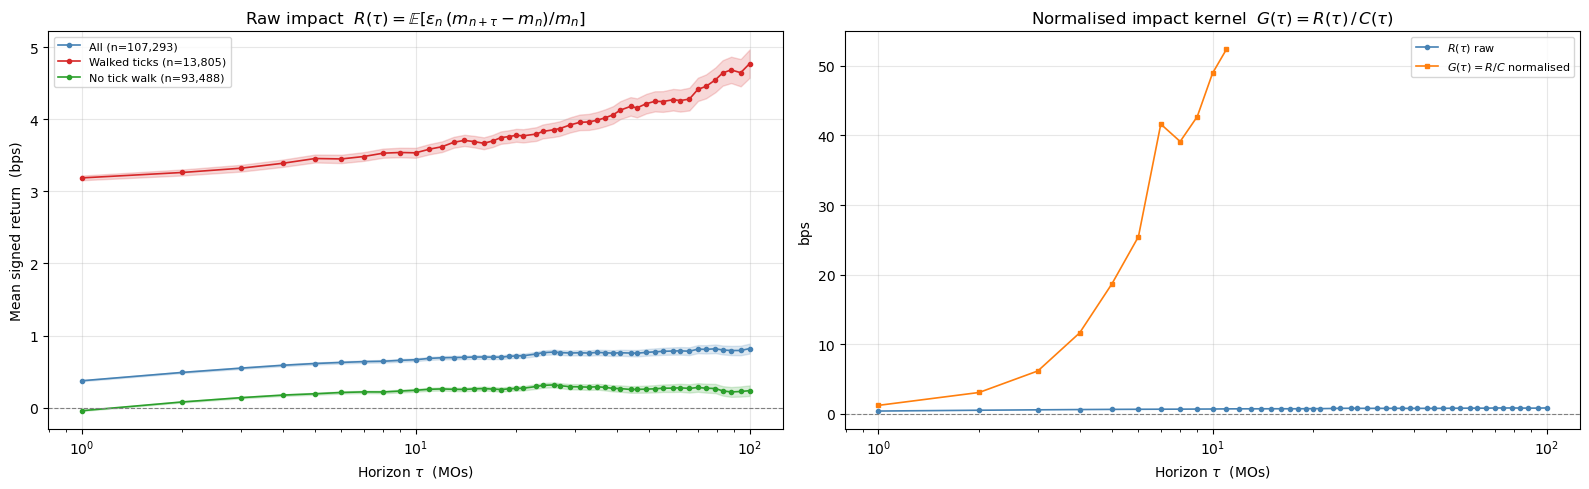

MOs total: 107,293
  walked ticks:    13,805
  no tick walk:    93,488
  R(1)  = +0.373 bps   C(1)  = 0.3136   G(1)  = +1.190 bps
  R(100) = +0.819 bps   C(100) = -0.0043   G(100) = n/a bps
  |C| > 0.01 for 11/47 horizons


In [7]:
am_triple.price_impact_propagator(split_regimes=True)

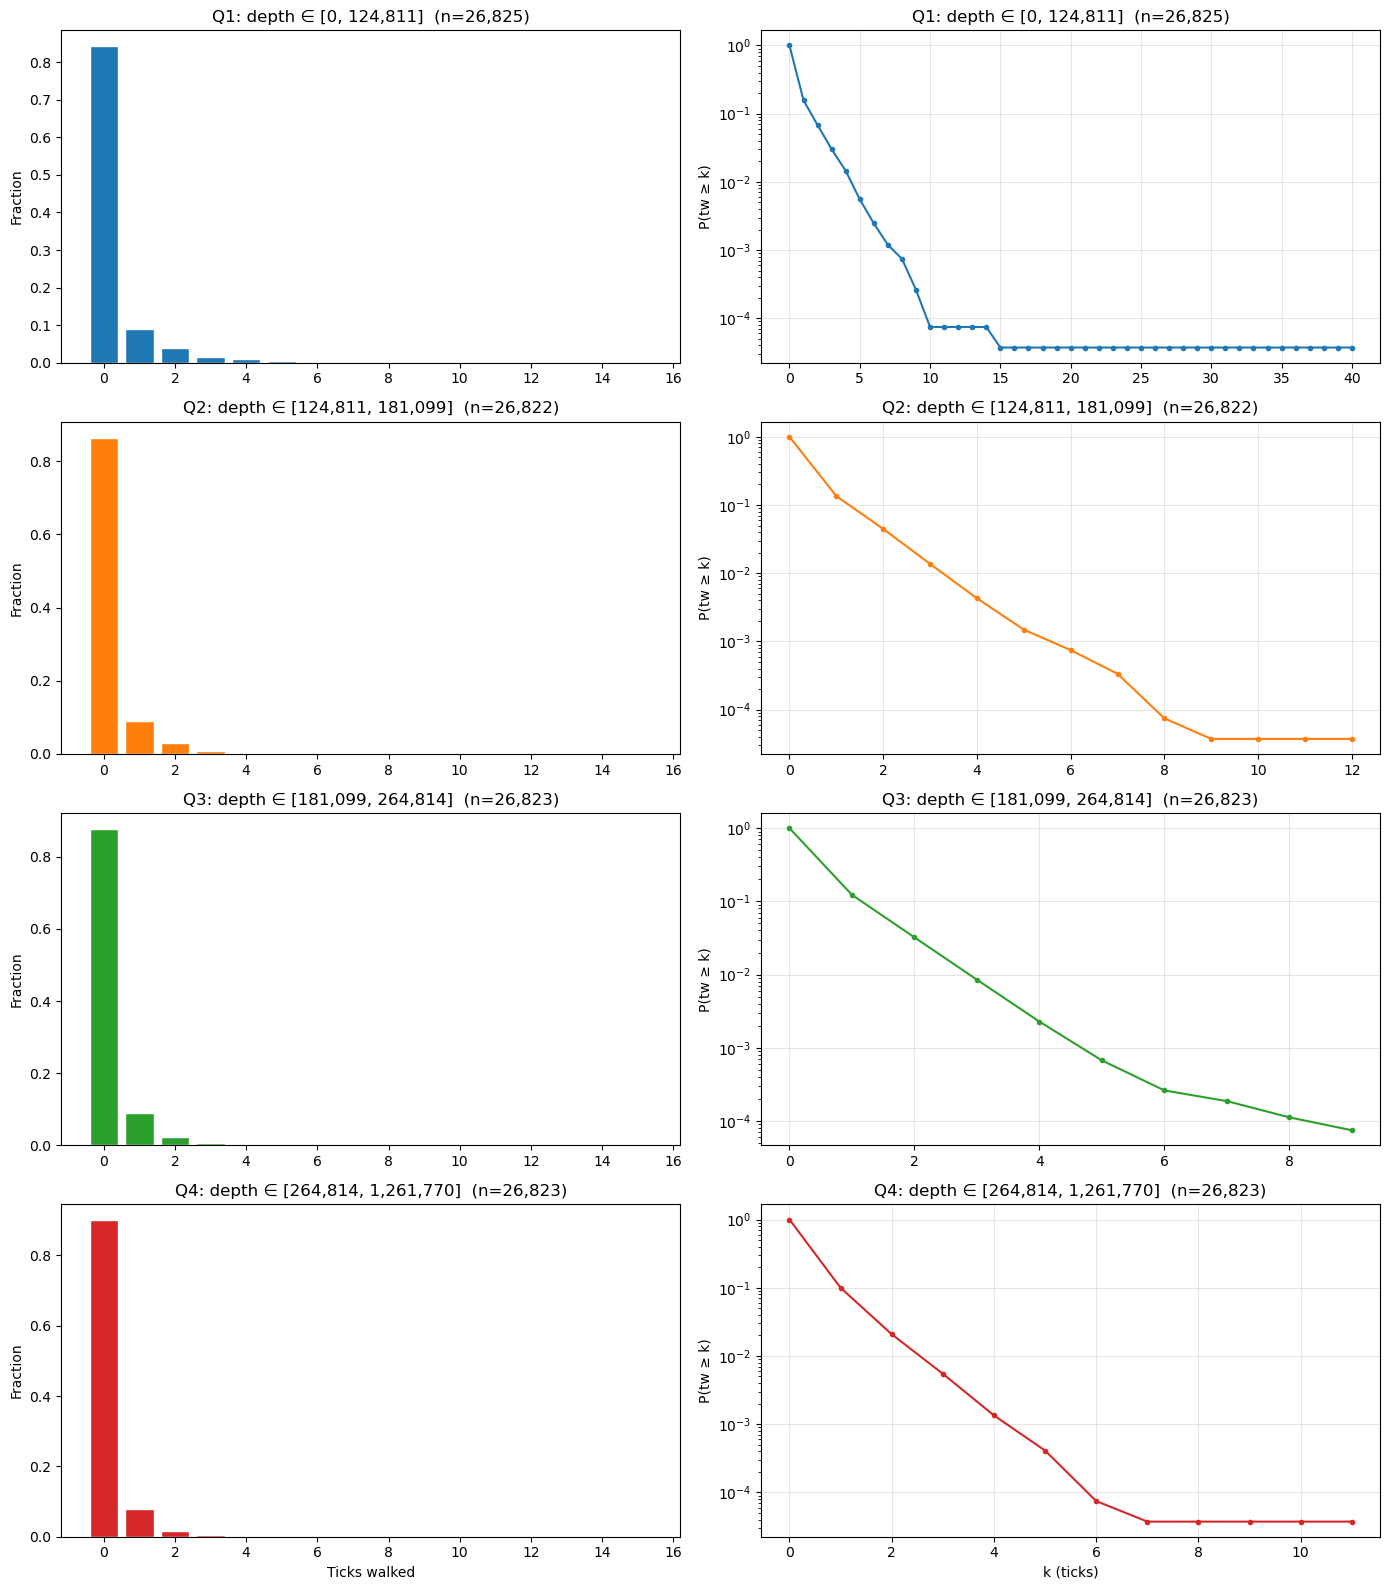


  Quartile         n   mean tw    P(>0)     P(≥5)
──────────────────────────────────────────────────
        Q1    26,825     0.281    15.7%     0.56%
        Q2    26,822     0.201    13.5%     0.15%
        Q3    26,823     0.167    12.3%     0.07%
        Q4    26,823     0.128    10.0%     0.04%


In [8]:
am_triple.price_impact_by_depth()

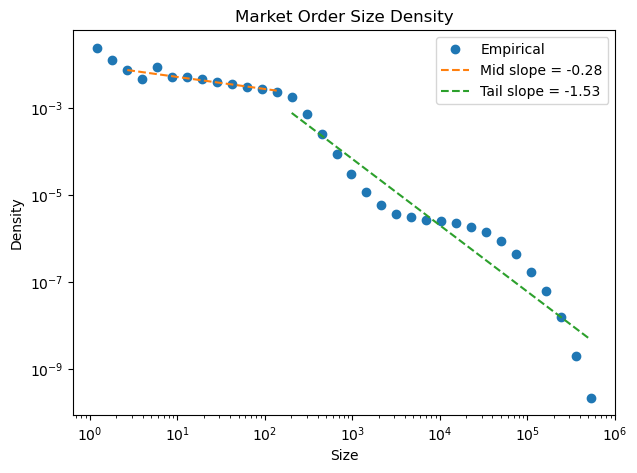

Mid slope  ≈ -0.277
Tail slope ≈ -1.525  (α ≈ 1.525)


In [9]:
am_triple.mo_size_distribution()

In [5]:
# ═══════════════════════════════════════════════════════════════════════════════
# Parallel lightweight simulations  (12 workers)
# ═══════════════════════════════════════════════════════════════════════════════


# ── Configuration ──────────────────────────────────────────────────────────
N_RUNS       = 500              # number of independent simulations
MAX_WORKERS  = 12              # parallel processes (one per CPU core)
T_PARALLEL   = 184337         # events per simulation (match the single-run T)
ARRIVAL_MODE = "hawkes_multivariate"
KERNEL_MODE  = "triple"

# Snapshot parameters (same as the main sim)
SNAPSHOT_ASSET = "KGHM"
SNAPSHOT_DAY   = "d20170110"
SNAPSHOT_TIME  = "10:00:00"
SNAPSHOT_TICK  = 0.05



# ── Launch parallel runs ──────────────────────────────────────────────────
print(f"Launching {N_RUNS} lightweight simulations "
      f"({MAX_WORKERS} workers, {T_PARALLEL:,} events each)...")
t0 = _time.time()

all_results_dual = Parallel(n_jobs=MAX_WORKERS, verbose=10)(
    delayed(_run_lightweight)(
        i, T_PARALLEL, ARRIVAL_MODE, KERNEL_MODE,
        SNAPSHOT_ASSET, SNAPSHOT_DAY, SNAPSHOT_TIME, SNAPSHOT_TICK,
    )
    for i in range(N_RUNS)
)

elapsed = _time.time() - t0
print(f"\nDone in {elapsed:.1f}s  ({elapsed/N_RUNS:.1f}s per run)")
print(f"Collected {len(all_results_dual)} runs:")
for r in all_results_dual:
    s = r['summary']
    print(f"  run {r['run_id']:>2d}: {s['n_fills']:>7,} fills, "
          f"{s['n_mos']:>6,} MOs  (buy={s['n_buy']:,}, sell={s['n_sell']:,})")

Launching 500 lightweight simulations (12 workers, 184,337 events each)...


[Parallel(n_jobs=12)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done   1 tasks      | elapsed:  3.2min
[Parallel(n_jobs=12)]: Done   8 tasks      | elapsed:  3.3min
[Parallel(n_jobs=12)]: Done  17 tasks      | elapsed:  6.2min
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:  9.3min
[Parallel(n_jobs=12)]: Done  37 tasks      | elapsed: 12.6min
[Parallel(n_jobs=12)]: Done  48 tasks      | elapsed: 13.1min
[Parallel(n_jobs=12)]: Done  61 tasks      | elapsed: 18.7min
[Parallel(n_jobs=12)]: Done  74 tasks      | elapsed: 21.5min
[Parallel(n_jobs=12)]: Done  89 tasks      | elapsed: 24.4min
[Parallel(n_jobs=12)]: Done 104 tasks      | elapsed: 27.6min
[Parallel(n_jobs=12)]: Done 121 tasks      | elapsed: 33.1min
[Parallel(n_jobs=12)]: Done 138 tasks      | elapsed: 36.0min
[Parallel(n_jobs=12)]: Done 157 tasks      | elapsed: 41.6min
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed: 44.9min
[Parallel(n_jobs=12)]: Done 197 tasks      | elapsed: 4


Done in 5823.5s  (11.6s per run)
Collected 500 runs:
  run  0:  24,111 fills, 10,692 MOs  (buy=5,593, sell=5,099)
  run  1:  23,703 fills, 10,548 MOs  (buy=5,370, sell=5,178)
  run  2:  23,823 fills, 10,482 MOs  (buy=5,400, sell=5,082)
  run  3:  24,336 fills, 10,493 MOs  (buy=5,384, sell=5,109)
  run  4:  24,199 fills, 10,845 MOs  (buy=5,613, sell=5,232)
  run  5:  23,602 fills, 10,526 MOs  (buy=5,424, sell=5,102)
  run  6:  23,975 fills, 10,755 MOs  (buy=5,656, sell=5,099)
  run  7:  23,834 fills, 10,742 MOs  (buy=5,666, sell=5,076)
  run  8:  23,862 fills, 10,790 MOs  (buy=5,557, sell=5,233)
  run  9:  24,332 fills, 10,857 MOs  (buy=5,590, sell=5,267)
  run 10:  24,401 fills, 10,648 MOs  (buy=5,568, sell=5,080)
  run 11:  23,941 fills, 10,372 MOs  (buy=5,320, sell=5,052)
  run 12:  23,702 fills, 10,549 MOs  (buy=5,374, sell=5,175)
  run 13:  23,899 fills, 10,815 MOs  (buy=5,543, sell=5,272)
  run 14:  24,147 fills, 10,714 MOs  (buy=5,496, sell=5,218)
  run 15:  23,956 fills, 10,621

[Parallel(n_jobs=12)]: Done 500 out of 500 | elapsed: 97.1min finished


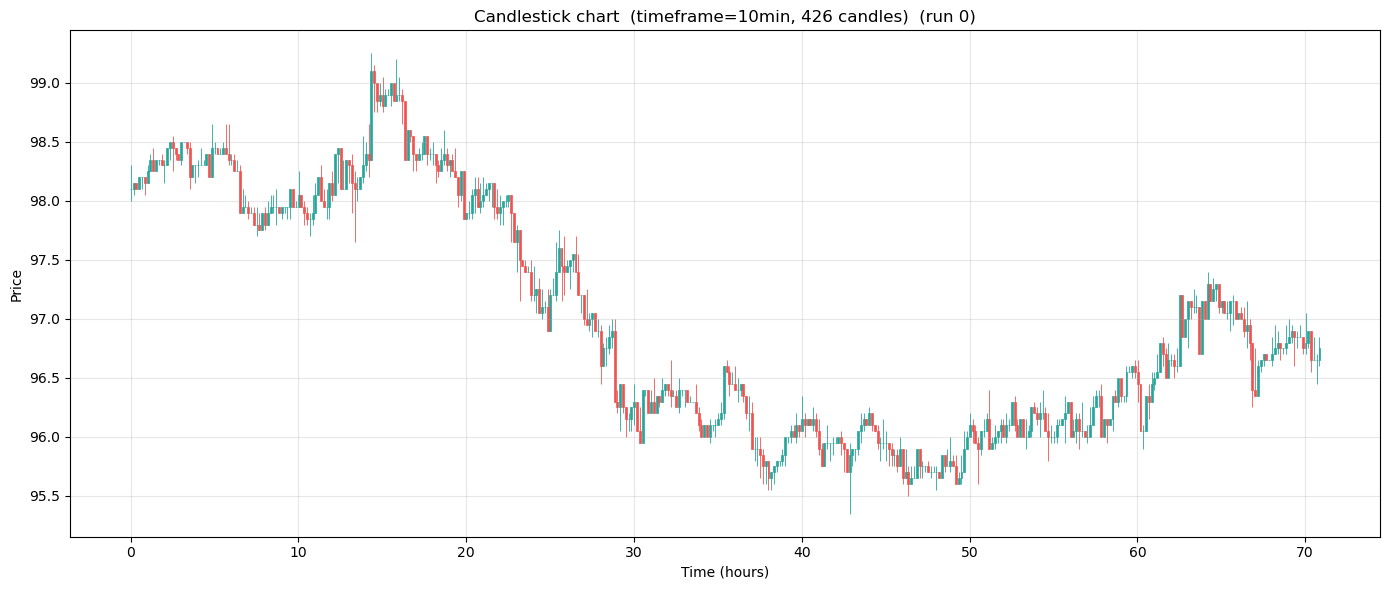

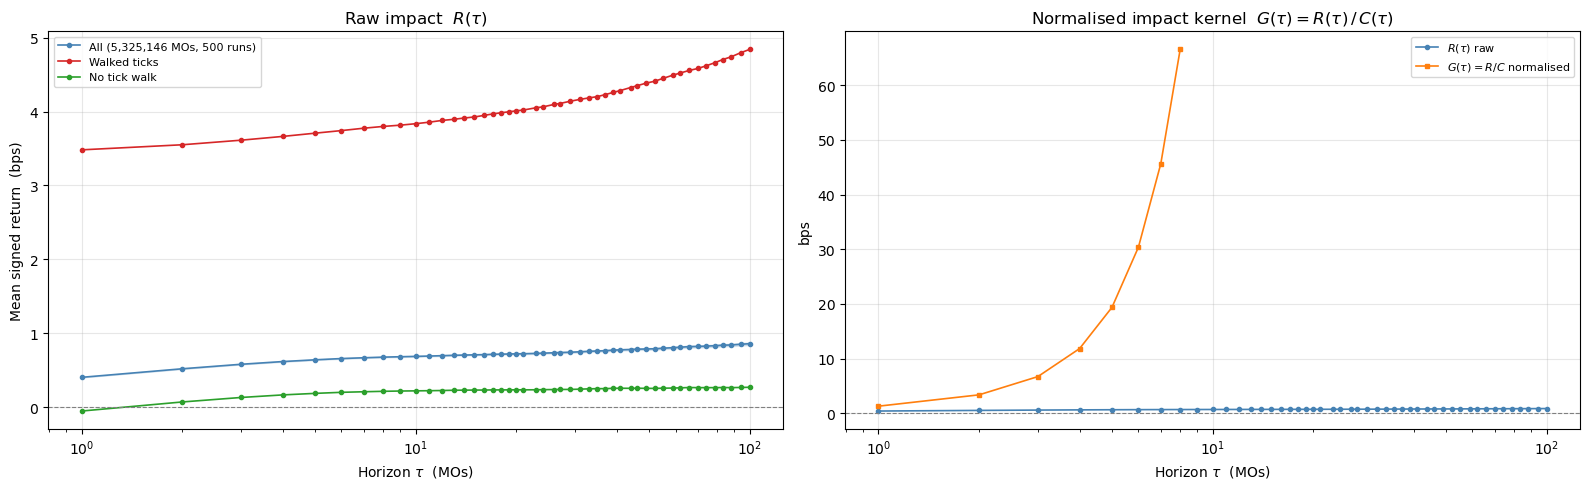

Runs: 500,  total MOs: 5,325,146
  R(1)  = +0.404 bps   C(1)  = 0.3120   G(1)  = +1.294 bps
  R(100) = +0.859 bps   C(100) = 0.0018   G(100) = n/a bps
Full sign series length: 5,325,146 MOs,  buy fraction: 0.515
Power-law exponent:  γ = 1.0635   (ρ(k) ~ k^{-1.0635})


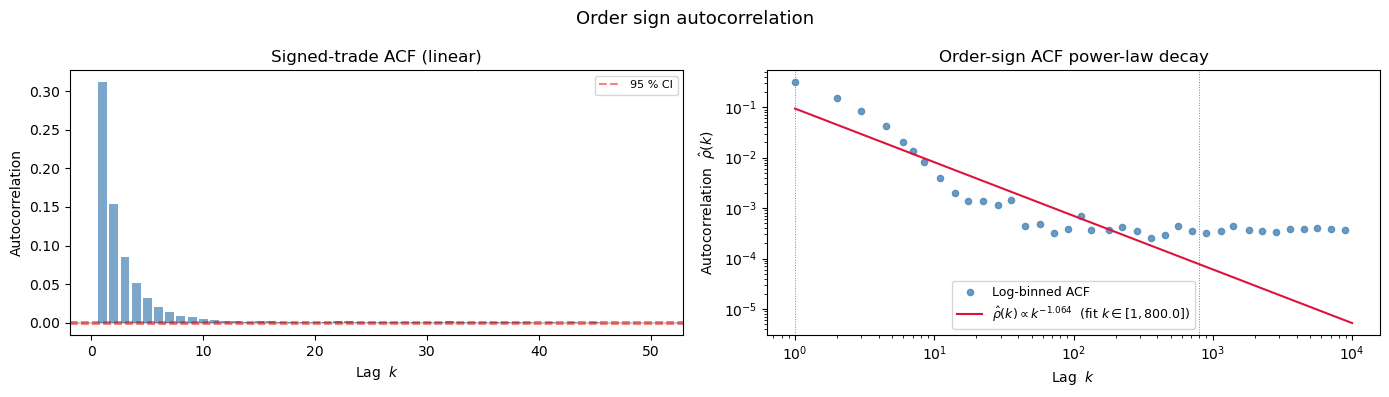

Average ACF power-law exponent:  γ = 1.8425  (from 500 runs)


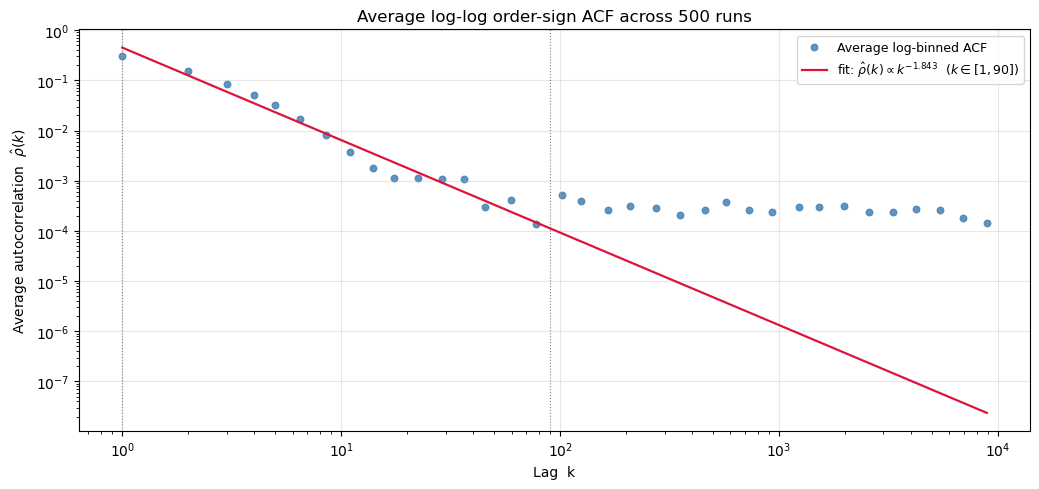

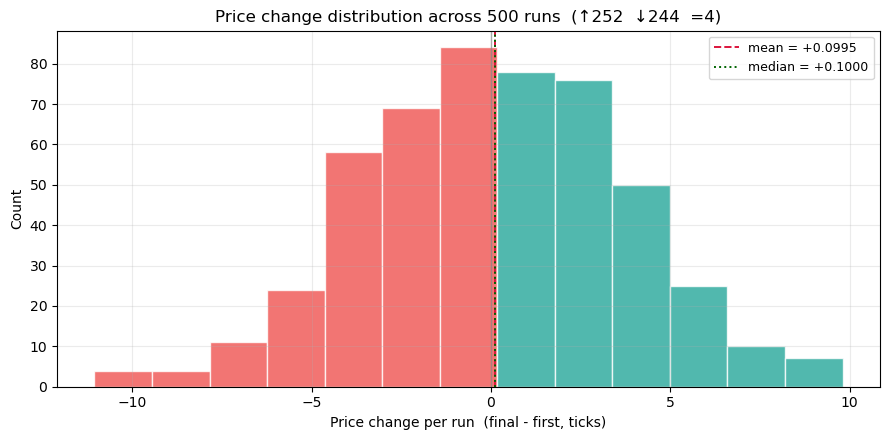

Price change stats: min=-11.0500, max=+9.8000, mean=+0.0995, std=3.6113


In [6]:
# ═══════════════════════════════════════════════════════════════════════════════
# Analyse parallel results — candlestick, propagator, ACF, final-price dispersion
# ═══════════════════════════════════════════════════════════════════════════════

# Candlestick for a single run (run 0)
plot_candlestick_compact(all_results_dual[2], timeframe=600.0, title_suffix="  (run 0)")

# Price-impact propagator averaged across all runs
price_impact_propagator_compact(all_results_dual, max_horizon=100,
                                split_regimes=True)

# Order-sign ACF pooled across all runs (legacy helper)
order_sign_acf_compact(all_results_dual)

# Average per-run ACF in log-log scale + power-law fit (new helper)
plot_average_acf_compact(all_results_dual, max_lag_loglog=10_000,
                         cap=90, n_log_bins=37)

# Histogram of each run's final traded price (new helper)
plot_final_price_histogram_compact(all_results_dual, bins=13)